In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

In [5]:
df = pd.read_csv('Village_data.csv')

In [6]:
df.head()

,Timestamp,Survey type,Village Name,Household ID (House No.),Name of Head of Household,Gender,Contact Number of Household,Social Category,Total Family Members,Main Occupation,...,Livelihood Schemes [PM Fasal Bima],Livelihood Schemes [Pension Schemes],Awareness about Gram Sabha meetings,Participation in village development,Major village issues,Most urgent need of the village,Suggestions for village development,Enumerator Name,UID,Date
0,01-12-2026 13:22,Baseline,Bajhedi,NaN,Mohan Singh,Male,9914104719,General,4,Service,...,Aware,Aware,No,Occasional,"Water, Education, Employment",Road improvements,Making of roads,Hitanshi,25bbl70047,01-12-2026
1,1/13/2026 12:48:58,Baseline,Baroli,144,Harshant veer,Male,NaN,Scheduled Tribe,4,Service,...,Aware,Aware,Yes,Occasional,"Water, Environment",Drainage system,Drainage system,Yashmi and Aditi,25bcs12827 and 25bcs10021,1/13/2026
2,01-12-2026 11:48,Baseline,Bhago Majra,NaN,Jaswinder kour,Female,9781068967,General,6,Agriculture,...,Not Aware,Not Aware,No,Never,Health,Healthcare,Cleaning of waste,Bhagyashree,24btt10013,01-12-2026
3,01-12-2026 13:48,Baseline,Bajhedi,NaN,Gurinder kaur,Female,8872445393,General,4,Business,...,Not Aware,Not Aware,Yes,Never,"Water, Health, Environment","Transport, Dispensary and pond purification",Regular transport and dispensary,Pushp Ankit kotwal,25bbl70011,01-12-2026
4,1/13/2026 11:19:16,Baseline,Bhago Majra,NaN,Kulwant Singh,Male,7696486215,General,5,Agriculture,...,Aware,Aware,Yes,Occasional,Environment,"All good there is gym in village,school ,every...",No,Kushagra Sharma,25BBE10175,1/13/2026


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (855, 75)


In [5]:
df.columns = df.columns.str.strip()
df['Total Family Members'] = pd.to_numeric(df['Total Family Members'], errors='coerce')

In [6]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ['Column Name', 'Missing Count']
missing_values[missing_values['Missing Count'] > 0]

,Column Name,Missing Count
3,Household ID (House No.),498
4,Name of Head of Household,1
6,Contact Number of Household,364
8,Total Family Members,1
15,Pregnant women received ANC services,209
17,Nutritional issues of children,784
18,Common diseases,435
27,Type of school,122
30,Reason for dropout,519
31,Access to digital devices,50


In [7]:
df.columns

Index(['Timestamp', 'Survey type', 'Village Name', 'Household ID (House No.)',
       'Name of Head of Household', 'Gender', 'Contact Number of Household',
       'Social Category', 'Total Family Members', 'Main Occupation',
       'Approx. Annual Household Income',
       'Distance to nearest health facility', 'Type of facility used',
       'ASHA/ANM visit', 'Immunization status of children (0-5)',
       'Pregnant women received ANC services',
       'Last delivery was institutional  (in any hospital)',
       'Nutritional issues  of children', 'Common diseases',
       'Toilet availability', 'Handwashing with soap',
       'Health Schemes   [Ayushman Bharat (PM-JAY)]',
       'Health Schemes   [Janani Suraksha Yojana]',
       'Health Schemes   [Janani Shishu Suraksha Karyakram]',
       'Health Schemes   [Poshan Abhiyaan / ICDS]',
       'Literacy status of household', 'Children enrolled in school',
       'Type of school', 'Distance to nearest school',
       'School dropout case

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 855 entries, 0 to 854
Data columns (total 75 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Timestamp                                              855 non-null    object 
 1   Survey type                                            855 non-null    object 
 2   Village Name                                           855 non-null    object 
 3   Household ID (House No.)                               357 non-null    object 
 4   Name of Head of Household                              854 non-null    object 
 5   Gender                                                 855 non-null    object 
 6   Contact Number of Household                            491 non-null    object 
 7   Social Category                                        855 non-null    object 
 8   Total Family Members                              

# Socio-Economic Indicators

# 1. Income Distribution Index

In [9]:
income_counts = df['Approx. Annual Household Income'].value_counts()

In [10]:
percentage_income = (income_counts/income_counts.sum())*100
percentage_income

Approx. Annual Household Income
1-3 lakh    34.035088
<1 lakh     33.216374
3-5 lakh    20.701754
>5 lakh     12.046784
Name: count, dtype: float64

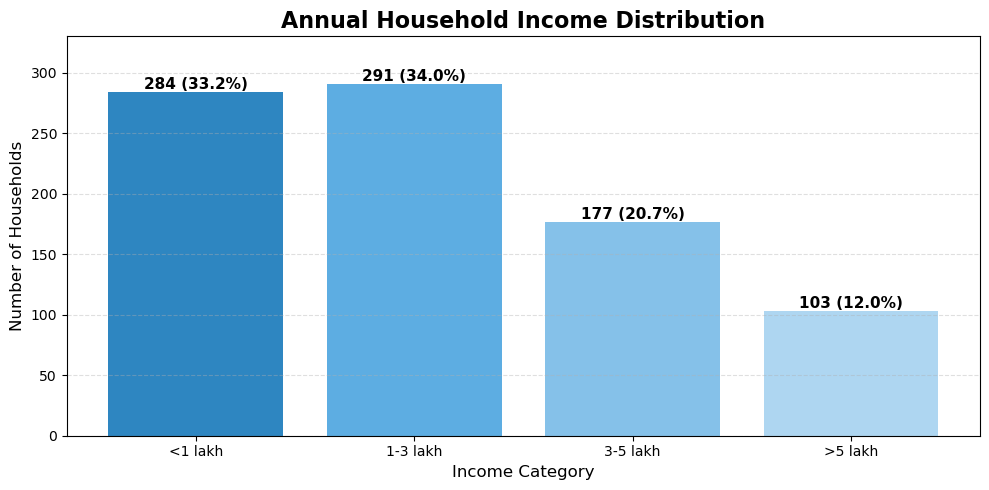

In [11]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
income_counts = df['Approx. Annual Household Income'].value_counts()
income_counts = income_counts[order]

plt.figure(figsize=(10,5))

colors = ['#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
bars = plt.bar(income_counts.index, income_counts.values, color=colors)

total = income_counts.sum()

for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)} ({percent:.1f}%)',
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

plt.title("Annual Household Income Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.ylim(0, 330)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2. Occupational Diversity Indicator

In [12]:
occupation_dist = df['Main Occupation'].value_counts(normalize=True) * 100
occupation_dist = occupation_dist.round(2)
print(occupation_dist)

Main Occupation
Agriculture                       36.73
Labour                            22.34
Service                           20.94
Business                           9.82
Agriculture, Business              2.81
Agriculture, Service               2.46
Agriculture, Labour                1.87
Service, Business                  1.40
Labour, Service                    1.05
Labour, Business                   0.23
Agriculture, Labour, Service       0.12
Agriculture, Service, Business     0.12
Agriculture, Labour, Business      0.12
Name: proportion, dtype: float64


In [13]:
df['Main Occupation'].value_counts()

Main Occupation
Agriculture                       314
Labour                            191
Service                           179
Business                           84
Agriculture, Business              24
Agriculture, Service               21
Agriculture, Labour                16
Service, Business                  12
Labour, Service                     9
Labour, Business                    2
Agriculture, Labour, Service        1
Agriculture, Service, Business      1
Agriculture, Labour, Business       1
Name: count, dtype: int64

In [14]:
df['Approx. Annual Household Income'] = df['Approx. Annual Household Income'].str.strip()
df['Main Occupation'] = df['Main Occupation'].str.strip()

In [15]:
order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
df['Approx. Annual Household Income'] = pd.Categorical(
    df['Approx. Annual Household Income'],
    categories=order,
    ordered=True)

income_occupation = pd.crosstab(
    df['Main Occupation'],
    df['Approx. Annual Household Income'])
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,79,127,79,29
"Agriculture, Business",1,8,6,9
"Agriculture, Labour",5,6,3,2
"Agriculture, Labour, Business",0,1,0,0
"Agriculture, Labour, Service",0,0,1,0
"Agriculture, Service",4,5,7,5
"Agriculture, Service, Business",0,0,0,1
Business,11,31,15,27
Labour,140,43,7,1


In [16]:
occupations = df['Main Occupation'].value_counts().index
income_occupation = income_occupation.loc[occupations]
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,79,127,79,29
Labour,140,43,7,1
Service,41,59,51,28
Business,11,31,15,27
"Agriculture, Business",1,8,6,9
"Agriculture, Service",4,5,7,5
"Agriculture, Labour",5,6,3,2
"Service, Business",0,5,6,1
"Labour, Service",3,4,2,0


In [17]:
top_occupations = df['Main Occupation'].value_counts().head(5).index
income_occupation = income_occupation.loc[top_occupations]

In [18]:
income_occupation

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Main Occupation,,,,
Agriculture,79,127,79,29
Labour,140,43,7,1
Service,41,59,51,28
Business,11,31,15,27
"Agriculture, Business",1,8,6,9


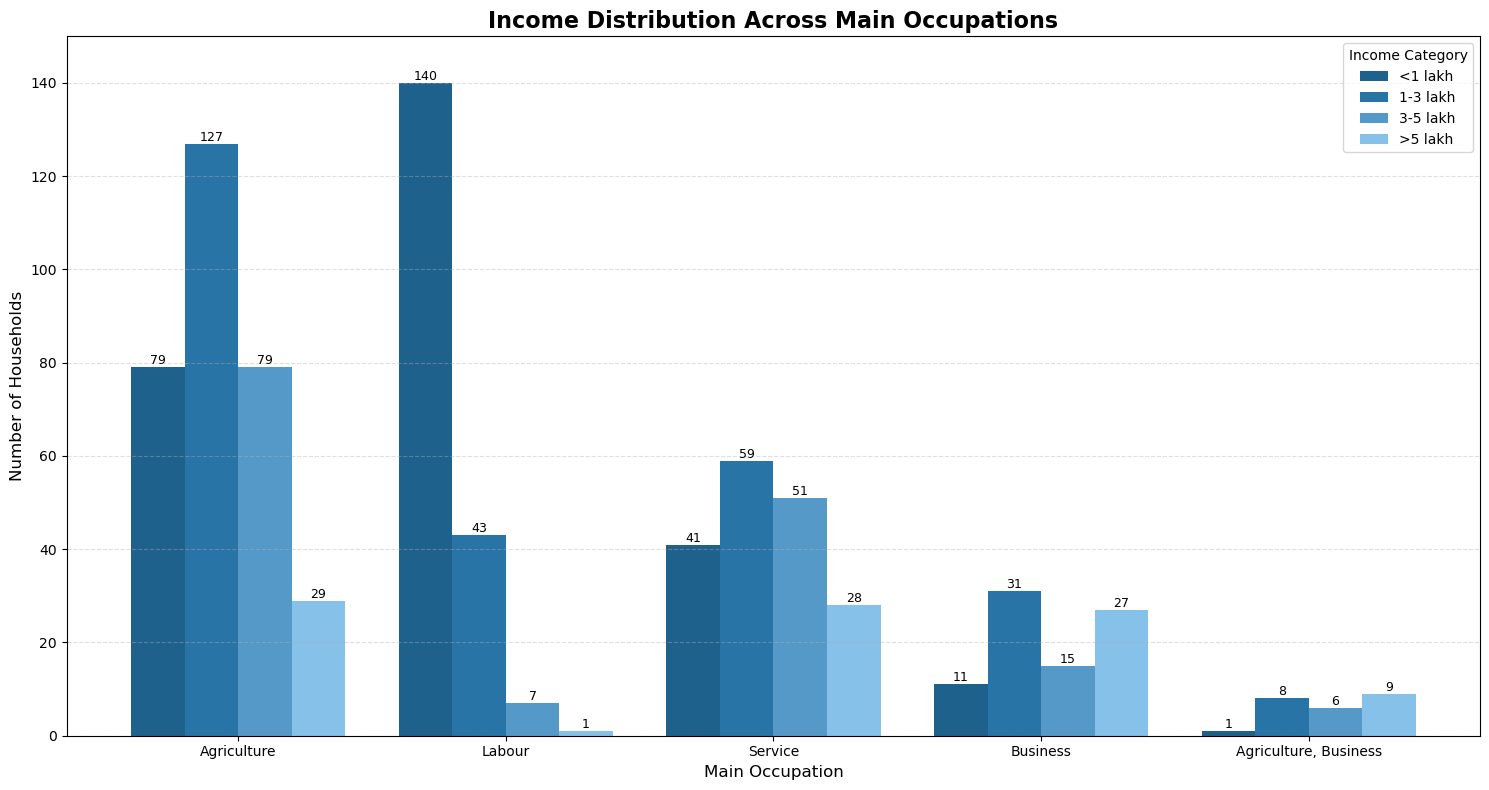

In [19]:
plt.figure(figsize=(15,8))

x = np.arange(len(income_occupation.index))
width = 0.2
colors = ['#1F618D', '#2874A6', '#5499C7', '#85C1E9']

for i, income_cat in enumerate(order):
    bars = plt.bar(x + i*width,
                   income_occupation[income_cat],
                   width,
                   label=income_cat,
                   color=colors[i])
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2,
                     height,
                     int(height),
                     ha='center',
                     va='bottom',
                     fontsize=9)

plt.xticks(x + width*1.5, income_occupation.index)
plt.xlabel("Main Occupation", fontsize=12)
plt.ylabel("Number of Households", fontsize=12)
plt.title("Income Distribution Across Main Occupations", fontsize=16, fontweight='bold')

plt.legend(title="Income Category")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, income_occupation.values.max()+10)
plt.tight_layout()
plt.show()

In [20]:
avg_family_size = df['Total Family Members'].mean()
print("Average Family Size:", round(avg_family_size,2))

Average Family Size: 5.63


# 3.Social Inclusion Profile

In [21]:
df['Social Category'].value_counts()

Social Category
General            483
Scheduled Caste    209
OBC                150
Scheduled Tribe     13
Name: count, dtype: int64

In [22]:
social_category = df['Social Category'].value_counts()
per_social_category = round((social_category/social_category.sum())*100,2)
per_social_category

Social Category
General            56.49
Scheduled Caste    24.44
OBC                17.54
Scheduled Tribe     1.52
Name: count, dtype: float64

In [23]:
round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [PM-KISAN]'], normalize='index') * 100,2)

Livelihood Schemes [PM-KISAN],Applied,Availed,Aware,Not Aware
Social Category,,,,
General,5.18,5.38,45.34,44.10
OBC,5.33,4.00,51.33,39.33
Scheduled Caste,4.78,1.91,44.98,48.33
Scheduled Tribe,0.00,0.00,69.23,30.77


In [24]:
social = df['Social Category'].value_counts()
social = social.sort_values(ascending=False)
total = social.sum()

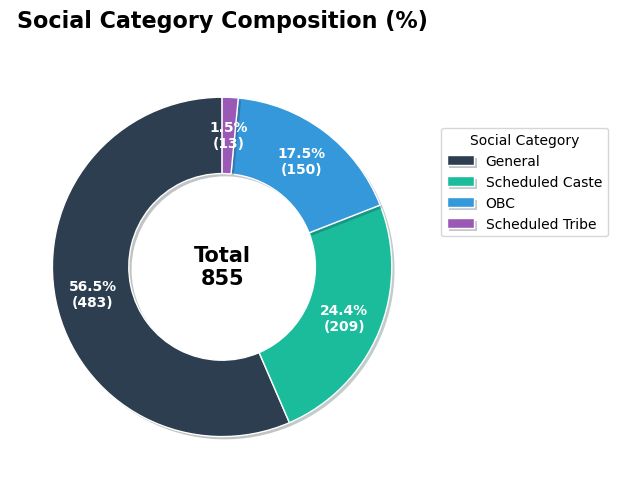

In [25]:
colors = ['#2C3E50', '#1ABC9C', '#3498DB', '#9B59B6']
plt.figure(figsize=(10,5))

wedges, texts, autotexts = plt.pie(social.values, startangle=90, colors=colors, wedgeprops=dict(width=0.45, edgecolor='white'),
                                   pctdistance=0.78, autopct=lambda p: f"{p:.1f}%\n({int(round(p*total/100))})")
for wedge in wedges:
    wedge.set_path_effects([
        pe.SimplePatchShadow(offset=(2, -2), alpha=0.25),
        pe.Normal()])

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.text(0, 0, f"Total\n{total}", ha='center', va='center', fontsize=15, fontweight='bold')
plt.title("Social Category Composition (%)", fontsize=16, fontweight='bold', pad=20)
plt.legend(wedges, social.index, title="Social Category", loc="center left", bbox_to_anchor=(1,0.7))
plt.tight_layout()
plt.show()

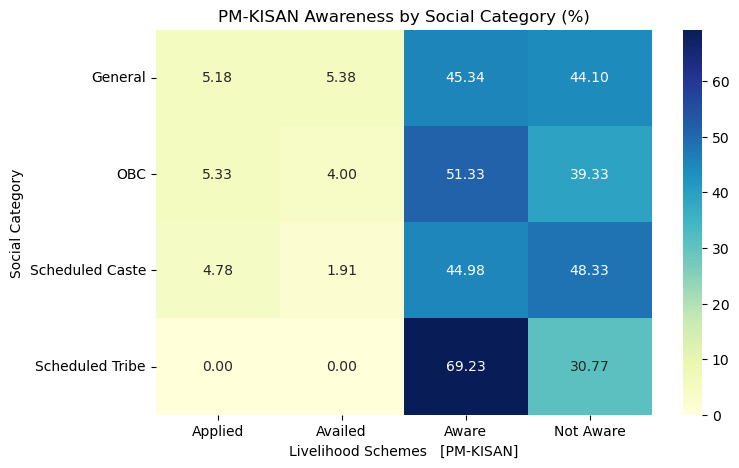

In [26]:
scheme_equity = pd.crosstab(
    df['Social Category'],
    df['Livelihood Schemes   [PM-KISAN]'],
    normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(scheme_equity,annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("PM-KISAN Awareness by Social Category (%)")
plt.show()

# Health & Nutrition Indicators Framework

# Institutional Delivery Rate

In [27]:
inst_delivery = df['Last delivery was institutional  (in any hospital)'].value_counts(normalize=True) * 100
round(inst_delivery,2)

Last delivery was institutional  (in any hospital)
YES    62.69
No     37.31
Name: proportion, dtype: float64

# Immunization Coverage (0–5 Years)

In [28]:
immunization = df['Immunization status of children (0-5)'].value_counts()
immunization

Immunization status of children (0-5)
Fully            614
Partially        145
Not immunised     96
Name: count, dtype: int64

In [29]:
immunization = df['Immunization status of children (0-5)'].value_counts(normalize=True) * 100
round(immunization,2)

Immunization status of children (0-5)
Fully            71.81
Partially        16.96
Not immunised    11.23
Name: proportion, dtype: float64

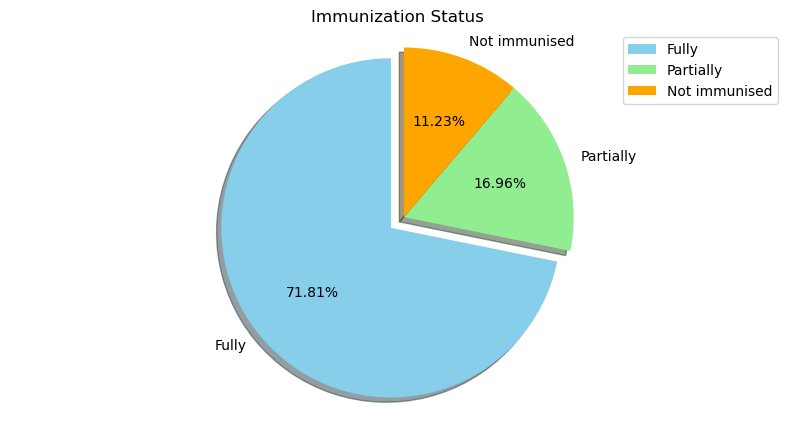

In [30]:
plt.figure(figsize=(10,5))
plt.pie(immunization.values, labels=immunization.index, autopct='%1.2f%%', startangle=90, explode = [0.1, 0, 0], shadow=True,
       colors=['skyblue','lightgreen','orange'])
plt.title("Immunization Status")
plt.axis('equal')
plt.legend()
plt.show()

# Healthcare Accessibility Gap

In [31]:
health_dist = df['Distance to nearest health facility'].value_counts()
health_dist

Distance to nearest health facility
1-5 km    373
>5 km     259
<1 km     223
Name: count, dtype: int64

In [32]:
health_dist = round(df['Distance to nearest health facility'].value_counts(normalize=True) * 100,2)
health_dist

Distance to nearest health facility
1-5 km    43.63
>5 km     30.29
<1 km     26.08
Name: proportion, dtype: float64

In [33]:
order = ['<1 km', '1-5 km', '>5 km']
health_dist = health_dist[order]

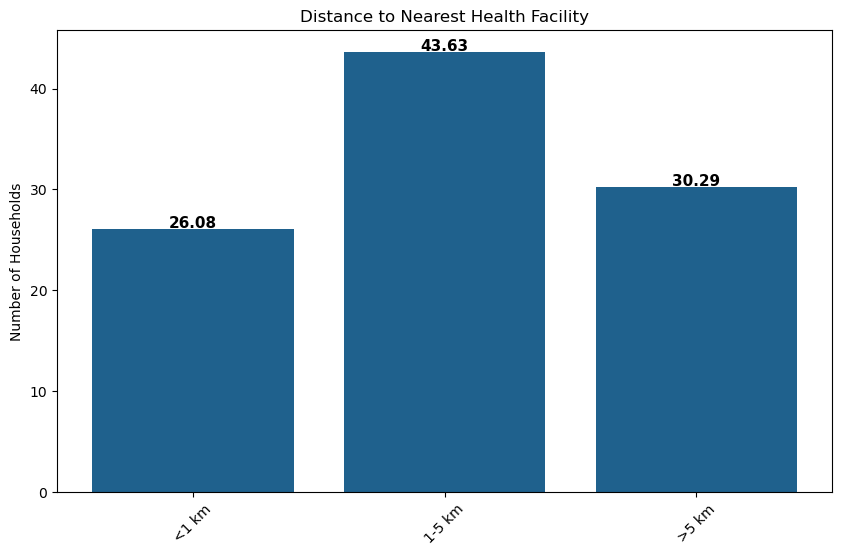

In [34]:
plt.figure(figsize=(10,6))
bars = plt.bar(health_dist.index, health_dist.values, color='#1F618D')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            bar.get_height(),
            ha='center',
            fontsize=11,
            fontweight='bold')
plt.title("Distance to Nearest Health Facility")
plt.ylabel("Number of Households")
plt.xticks(rotation=45)
plt.show()

# Disease Prevalence Rate

In [35]:
df['Common diseases'].value_counts()

Common diseases
BP                               168
BP, Diabetes                     103
Diabetes                          81
BP, Diabetes, Respiratory         18
Respiratory                       11
BP, Respiratory                   10
BP, None                           7
Diabetes, None                     3
BP, TB, Respiratory                3
TB                                 3
BP, Diabetes, TB                   3
BP, TB                             3
BP, Diabetes, TB, Respiratory      2
TB, None                           1
TB, Respiratory                    1
Diabetes, Respiratory              1
Diabetes, TB                       1
BP, Diabetes, None                 1
Name: count, dtype: int64

In [36]:
diseases_rate = df['Common diseases'].notna().mean() * 100
print(f'Diseases Rate = {round(diseases_rate,2)}%')

Diseases Rate = 49.12%


In [37]:
common_diseases = df['Common diseases'].str.split(',').explode().str.strip()

In [38]:
common_diseases_count = common_diseases.value_counts()
common_diseases_count

Common diseases
BP             318
Diabetes       213
Respiratory     46
TB              17
None            12
Name: count, dtype: int64

In [39]:
common_diseases_percentage = round((common_diseases_count/common_diseases_count.sum())*100,2)
common_diseases_percentage

Common diseases
BP             52.48
Diabetes       35.15
Respiratory     7.59
TB              2.81
None            1.98
Name: count, dtype: float64

# Scheme Awareness & Utilization (Health)

In [40]:
pmjay = round(df['Health Schemes   [Ayushman Bharat (PM-JAY)]'].value_counts(normalize=True) * 100,2)
pmjay

Health Schemes   [Ayushman Bharat (PM-JAY)]
Aware        46.90
Not aware    34.04
Availed      10.18
Applied       8.89
Name: proportion, dtype: float64

In [41]:
jsy = round(df['Health Schemes   [Janani Suraksha Yojana]'].value_counts(normalize=True) * 100,2)
jsy

Health Schemes   [Janani Suraksha Yojana]
Not aware    55.79
Aware        37.78
Availed       3.27
Applied       3.16
Name: proportion, dtype: float64

# Education & Digital Literacy Indicators

# 1. Household Literacy Rate

In [42]:
literacy = df['Literacy status of household'].value_counts()
literacy

Literacy status of household
Partially literate    408
All literate          378
Mostly illiterate      69
Name: count, dtype: int64

In [43]:
literacy_percent = round(df['Literacy status of household'].value_counts(normalize=True) * 100,2)
literacy_percent

Literacy status of household
Partially literate    47.72
All literate          44.21
Mostly illiterate      8.07
Name: proportion, dtype: float64

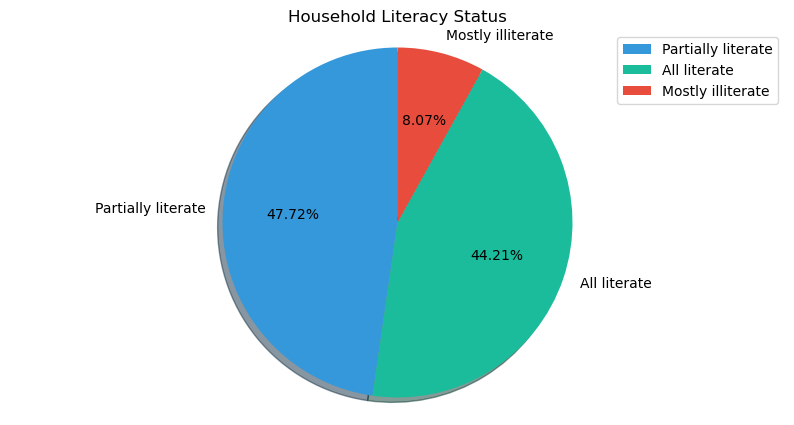

In [44]:
plt.figure(figsize=(10,5))
plt.pie(literacy_percent.values, labels=literacy_percent.index, autopct='%1.2f%%', startangle=90, colors=['#3498DB','#1ABC9C','#E74C3C'], shadow=True)
plt.title("Household Literacy Status")
plt.axis('equal')
plt.legend()
plt.show()

# 2. School Dropout Rate

In [45]:
dropout = df['School dropout cases  in the household'].value_counts()
dropout

School dropout cases  in the household
NO        679
YES       128
Partia     48
Name: count, dtype: int64

In [46]:
dropout_percent = round(df['School dropout cases  in the household'].value_counts(normalize=True) * 100,2)
dropout_percent

School dropout cases  in the household
NO        79.42
YES       14.97
Partia     5.61
Name: proportion, dtype: float64

In [47]:
reasons = df['Reason for dropout'].value_counts()
reasons

Reason for dropout
Financial                                     119
Lack of interest                               88
Domestic work                                  59
Migration                                      49
Financial, Domestic work                       10
Financial, Migration                            5
Domestic work, Lack of interest                 3
Financial, Lack of interest                     2
Financial, Domestic work, Lack of interest      1
Name: count, dtype: int64

In [48]:
reasons_percent = round(df['Reason for dropout'].value_counts(normalize=True)*100,2)
reasons_percent

Reason for dropout
Financial                                     35.42
Lack of interest                              26.19
Domestic work                                 17.56
Migration                                     14.58
Financial, Domestic work                       2.98
Financial, Migration                           1.49
Domestic work, Lack of interest                0.89
Financial, Lack of interest                    0.60
Financial, Domestic work, Lack of interest     0.30
Name: proportion, dtype: float64

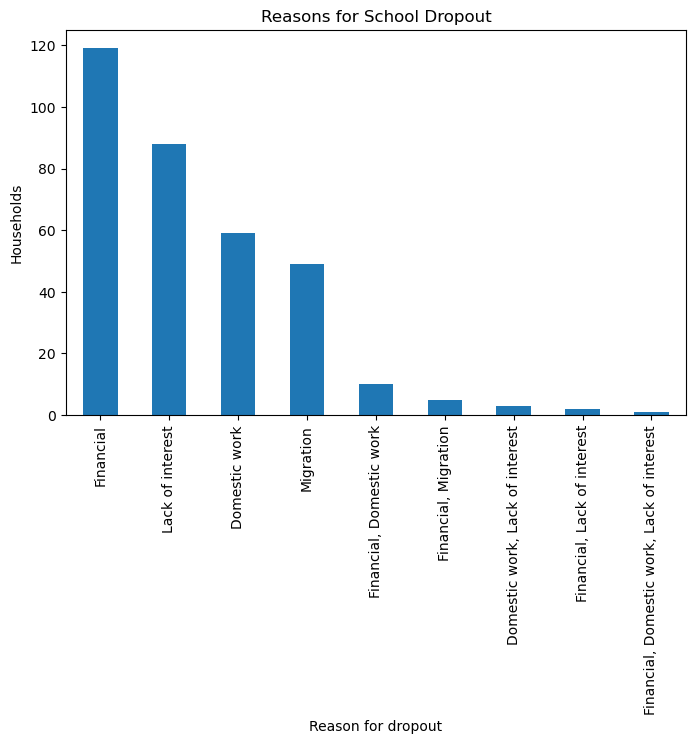

In [49]:
plt.figure(figsize=(8,5))
reasons.plot(kind='bar')
plt.title("Reasons for School Dropout")
plt.ylabel("Households")
plt.xticks(rotation=90)
plt.show()

In [50]:
reasons_strip = df['Reason for dropout'].str.split(',').explode().str.strip()

In [51]:
reasons_value = reasons_strip.value_counts()
reasons_value

Reason for dropout
Financial           137
Lack of interest     94
Domestic work        73
Migration            54
Name: count, dtype: int64

In [52]:
reasons_percentage = round((reasons_value/reasons_value.sum())*100,2)
reasons_percentage

Reason for dropout
Financial           38.27
Lack of interest    26.26
Domestic work       20.39
Migration           15.08
Name: count, dtype: float64

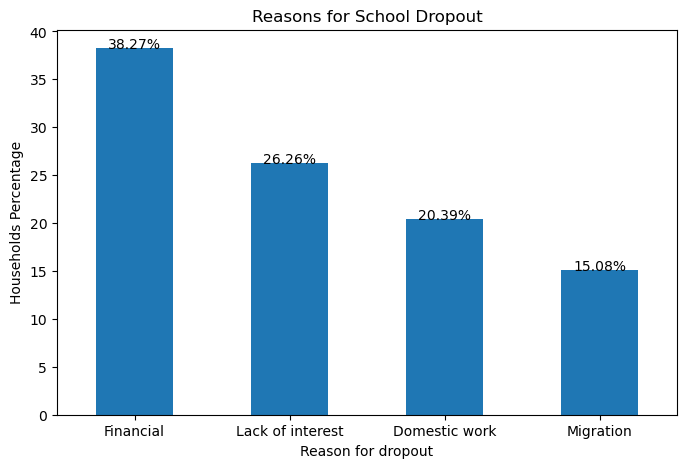

In [53]:
plt.figure(figsize=(8,5))
reasons_percentage.plot(kind='bar')
for i, v in enumerate(reasons_percentage.values):
    plt.text(i, v, f'{v:.2f}%', ha='center')
plt.title("Reasons for School Dropout")
plt.ylabel("Households Percentage")
plt.xticks(rotation=0)
plt.show()

# 3. Digital Divide Index

In [54]:
digital = df['Access to digital devices'].value_counts()
digital

Access to digital devices
Smartphone            599
Smartphone, Laptop    183
Laptop                 21
Smartphone, None        2
Name: count, dtype: int64

In [55]:
digital_percent = round(df['Access to digital devices'].value_counts(normalize=True) * 100,2)
digital_percent

Access to digital devices
Smartphone            74.41
Smartphone, Laptop    22.73
Laptop                 2.61
Smartphone, None       0.25
Name: proportion, dtype: float64

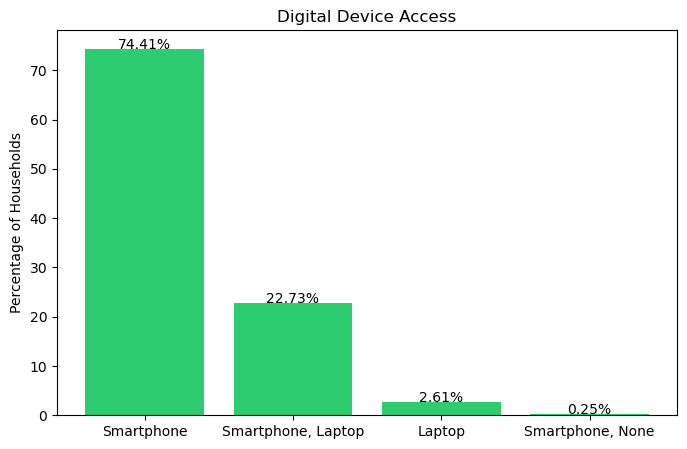

In [56]:
plt.figure(figsize=(8,5))
plt.bar(digital_percent.index, digital_percent.values, color='#2ECC71')
for i,v in enumerate(digital_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

In [57]:
digital_values = df['Access to digital devices'].str.split(',').explode().str.strip()

In [58]:
digital_count = digital_values.value_counts()
digital_count

Access to digital devices
Smartphone    784
Laptop        204
None            2
Name: count, dtype: int64

In [59]:
digital_percentage = round((digital_count/digital_count.sum())*100,2)
digital_percentage

Access to digital devices
Smartphone    79.19
Laptop        20.61
None           0.20
Name: count, dtype: float64

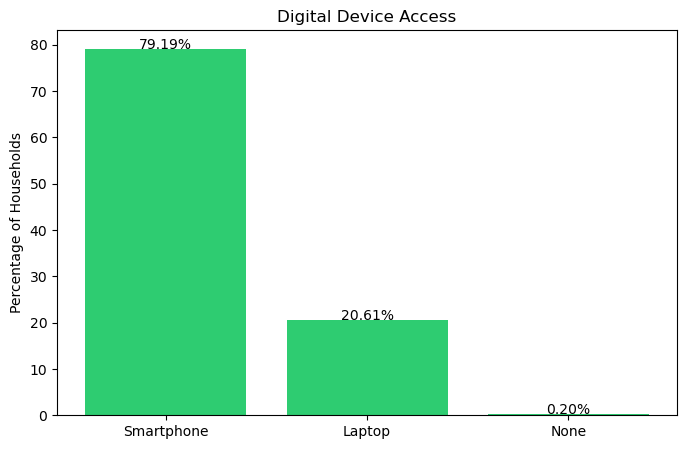

In [60]:
plt.figure(figsize=(8,5))
plt.bar(digital_percentage.index, digital_percentage.values, color='#2ECC71')
for i,v in enumerate(digital_percentage.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Digital Device Access")
plt.ylabel("Percentage of Households")
plt.show()

# 4. Gender Gap in Higher Education

In [61]:
girls_edu = df['Girls continuing education beyond Class X'].value_counts()
girls_edu

Girls continuing education beyond Class X
YES    630
No     225
Name: count, dtype: int64

In [62]:
girls_edu_percent = round(df['Girls continuing education beyond Class X'].value_counts(normalize=True)*100,2)
girls_edu_percent

Girls continuing education beyond Class X
YES    73.68
No     26.32
Name: proportion, dtype: float64

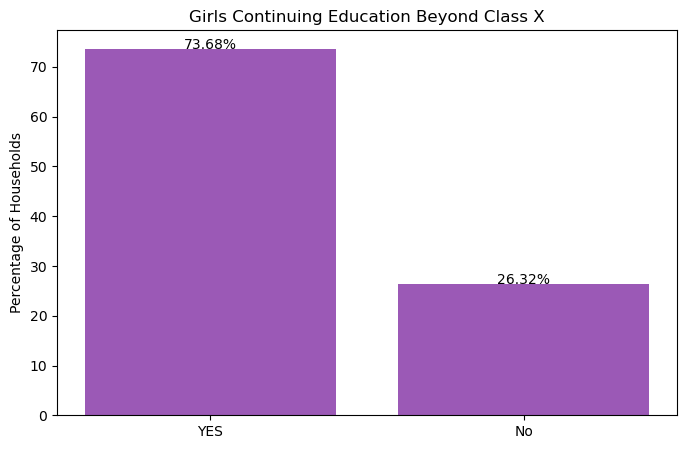

In [63]:
plt.figure(figsize=(8,5))
plt.bar(girls_edu_percent.index, girls_edu_percent.values, color='#9B59B6')

for i,v in enumerate(girls_edu_percent.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.title("Girls Continuing Education Beyond Class X")
plt.ylabel("Percentage of Households")
plt.show()

# 5. Remedial Support Demand

In [64]:
remedial = df['Need for remedial/coaching support'].value_counts()
remedial

Need for remedial/coaching support
No     466
Yes    389
Name: count, dtype: int64

In [65]:
remedial_percent = round(df['Need for remedial/coaching support'].value_counts(normalize=True)*100,2)
remedial_percent

Need for remedial/coaching support
No     54.5
Yes    45.5
Name: proportion, dtype: float64

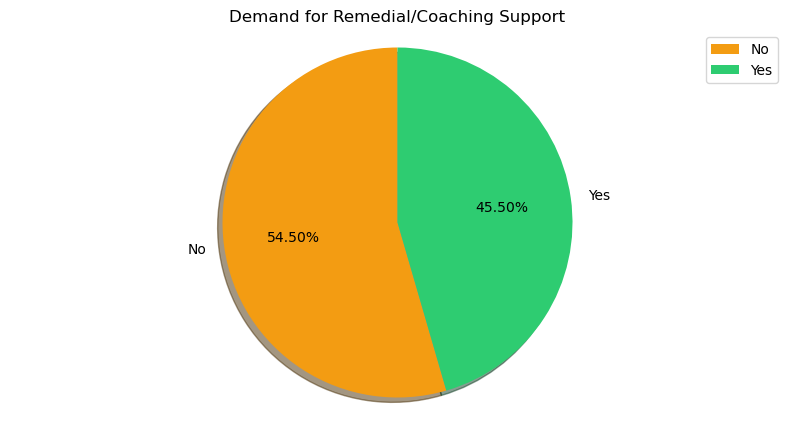

In [66]:
plt.figure(figsize=(10,5))
plt.pie(remedial_percent.values, labels=remedial_percent.index, autopct='%1.2f%%', colors=['#F39C12','#2ECC71'], startangle=90, shadow=True)
plt.title("Demand for Remedial/Coaching Support")
plt.axis('equal')
plt.legend()
plt.show()

# Water, Sanitation & Hygiene (WASH) Indicators

# 1. Safe Drinking Water Access

In [67]:
water_source = df['Source of drinking water'].value_counts()
water_source

Source of drinking water
Tap                                   527
Hand pump                              66
Tap, Hand pump                         53
Tap, Tanker                            46
Tanker                                 45
Tap, Hand pump, Well                   24
Tap, Well                              16
Well                                   15
Tap, Hand pump, Tanker                 15
Tap, Hand pump, Well, Tanker            8
Tap, Pond                               6
Hand pump, Tanker                       5
Tap, Hand pump, Pond, Tanker            4
Pond                                    3
Tap, Hand pump, Well, Pond, Tanker      3
Well, Tanker                            3
Hand pump, Well                         3
Hand pump, Well, Pond, Tanker           2
Tap, Well, Tanker                       2
Tap, Hand pump, Well, Pond              2
Pond, Tanker                            2
Tap, Well, Pond, Tanker                 1
Tap, Well, Pond                         1
Tap, Pond

In [68]:
water_source_split = df['Source of drinking water'].str.split(',').explode().str.strip()

In [69]:
water_source_count = water_source_split.value_counts()
water_source_count

Source of drinking water
Tap          709
Hand pump    187
Tanker       137
Well          81
Pond          27
Name: count, dtype: int64

In [70]:
water_source_percentage = round((water_source_count/water_source_count.sum())*100,2)
water_source_percentage

Source of drinking water
Tap          62.14
Hand pump    16.39
Tanker       12.01
Well          7.10
Pond          2.37
Name: count, dtype: float64

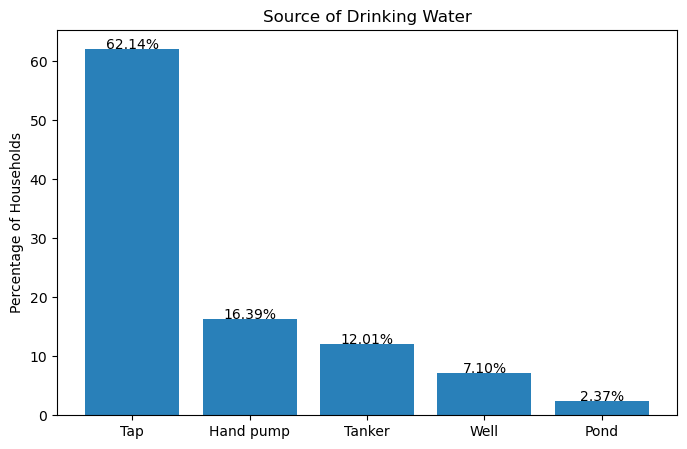

In [71]:
plt.figure(figsize=(8,5))
bars = plt.bar(water_source_percentage.index, water_source_percentage.values, color='#2980B9')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')

plt.title("Source of Drinking Water")
plt.ylabel("Percentage of Households")
plt.xticks()
plt.show()

In [72]:
water_quality = df['Quality of drinking water'].value_counts(normalize=True) * 100
round(water_quality,2)

Quality of drinking water
Good       72.40
Average    25.15
Poor        2.46
Name: proportion, dtype: float64

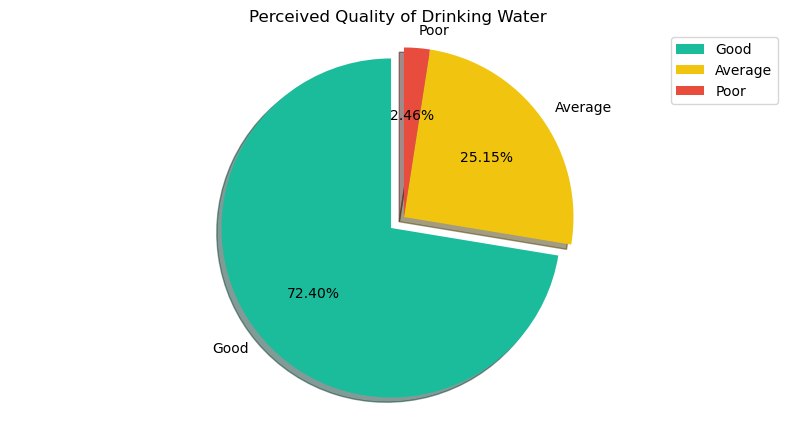

In [73]:
plt.figure(figsize=(10,5))
plt.pie(water_quality.values, labels=water_quality.index, autopct='%1.2f%%', explode=[0.1,0,0], colors=['#1ABC9C','#F1C40F','#E74C3C'], 
        startangle=90, shadow=True)
plt.title("Perceived Quality of Drinking Water")
plt.axis('equal')
plt.legend()
plt.show()

# 2. Sanitation Coverage

In [74]:
toilet = df['Toilet availability'].value_counts(normalize=True) * 100
round(toilet,2)

Toilet availability
YES    95.79
NO      4.21
Name: proportion, dtype: float64

In [75]:
handwash = df['Handwashing with soap'].value_counts(normalize=True) * 100
round(handwash,2)

Handwashing with soap
Always       81.29
Sometimes    16.73
Rarely        1.99
Name: proportion, dtype: float64

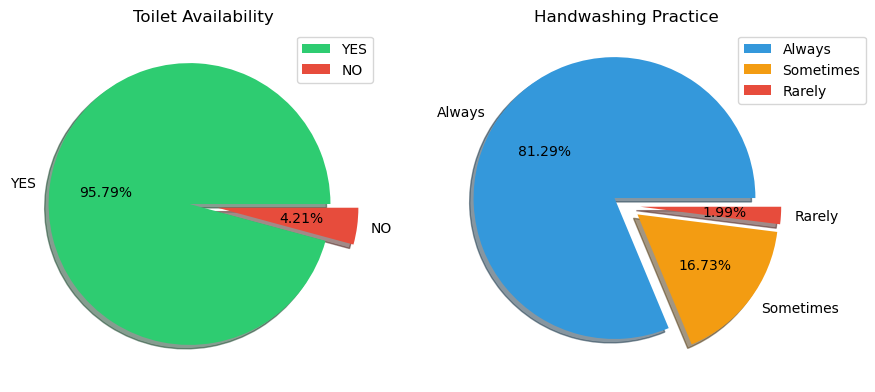

In [76]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.pie(toilet.values, labels=toilet.index, autopct='%1.2f%%',colors=['#2ECC71','#E74C3C'], explode=[0.1,0.1], shadow=True)
plt.title("Toilet Availability")
plt.legend()

plt.subplot(1,2,2)
plt.pie(handwash.values, labels=handwash.index, autopct='%1.2f%%',colors=['#3498DB','#F39C12','#E74C3C'], explode=[0.1,0.1,0.1], shadow=True)
plt.title("Handwashing Practice")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# 3. Waste Management Efficiency

In [77]:
waste = df['Solid waste disposal method'].value_counts()
waste

Solid waste disposal method
Door-to-door                  423
Open dumping                  346
Open dumping, Burning          40
Burning                        31
Door-to-door, Open dumping     13
Door-to-door, Burning           2
Name: count, dtype: int64

In [78]:
waste_percent = round(df['Solid waste disposal method'].value_counts(normalize=True)*100,2)
waste_percent

Solid waste disposal method
Door-to-door                  49.47
Open dumping                  40.47
Open dumping, Burning          4.68
Burning                        3.63
Door-to-door, Open dumping     1.52
Door-to-door, Burning          0.23
Name: proportion, dtype: float64

In [79]:
waste_split = df['Solid waste disposal method'].str.split(',').explode().str.strip()

In [80]:
waste_split_count = waste_split.value_counts()
waste_split_count

Solid waste disposal method
Door-to-door    438
Open dumping    399
Burning          73
Name: count, dtype: int64

In [81]:
waste_split_percentage = round((waste_split_count / waste_split_count.sum()) * 100, 2)
waste_split_percentage

Solid waste disposal method
Door-to-door    48.13
Open dumping    43.85
Burning          8.02
Name: count, dtype: float64

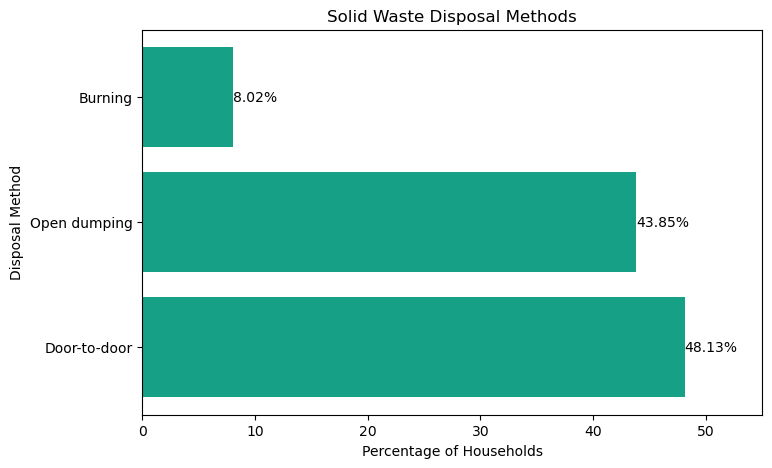

In [82]:
plt.figure(figsize=(8,5))
bars = plt.barh(waste_split_percentage.index, waste_split_percentage.values, color='#16A085')
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}%",
             va='center')

plt.title("Solid Waste Disposal Methods")
plt.xlabel("Percentage of Households")
plt.ylabel("Disposal Method")
plt.xlim(0,55)
plt.show()

# 4.Open Defecation Status

In [83]:
od = df['Open defecation in village'].value_counts(normalize=True) * 100
round(od,2)

Open defecation in village
No     63.16
Yes    36.84
Name: proportion, dtype: float64

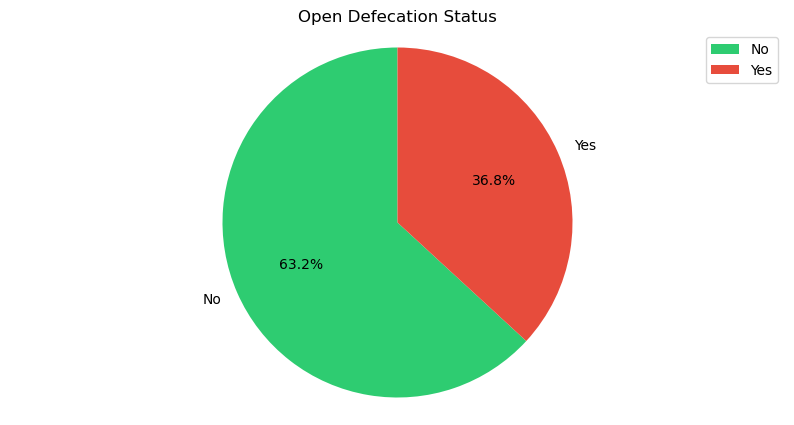

In [84]:
plt.figure(figsize=(10,5))
plt.pie(od.values, labels=od.index, autopct='%1.1f%%', colors=['#2ECC71','#E74C3C'], startangle=90)
plt.title("Open Defecation Status")
plt.axis('equal')
plt.legend()
plt.show()

# Environmental & Disaster Resilience Indicators

# 1. Environmental Stress Index

In [85]:
env_stress = df['Major environmental problems'].value_counts()
env_stress

Major environmental problems
Solid waste                                                                             248
Groundwater depletion                                                                   159
Flooding                                                                                111
Crop residue burning                                                                     56
Soil degradation                                                                         48
Flooding, Solid waste                                                                    32
Groundwater depletion, Solid waste                                                       30
Groundwater depletion, Flooding                                                          25
Crop residue burning, Soil degradation                                                   18
Crop residue burning, Solid waste                                                        16
Groundwater depletion, Flooding, Solid waste       

In [86]:
env_stress = df['Major environmental problems'].str.split(',').explode().str.strip()

In [87]:
env_stress_counts = env_stress.value_counts()
env_stress_counts

Major environmental problems
Solid waste              381
Groundwater depletion    291
Flooding                 216
Crop residue burning     141
Soil degradation         133
Name: count, dtype: int64

In [88]:
percentage_env_stress_counts = round(env_stress.value_counts(normalize=True)*100,2)
percentage_env_stress_counts

Major environmental problems
Solid waste              32.79
Groundwater depletion    25.04
Flooding                 18.59
Crop residue burning     12.13
Soil degradation         11.45
Name: proportion, dtype: float64

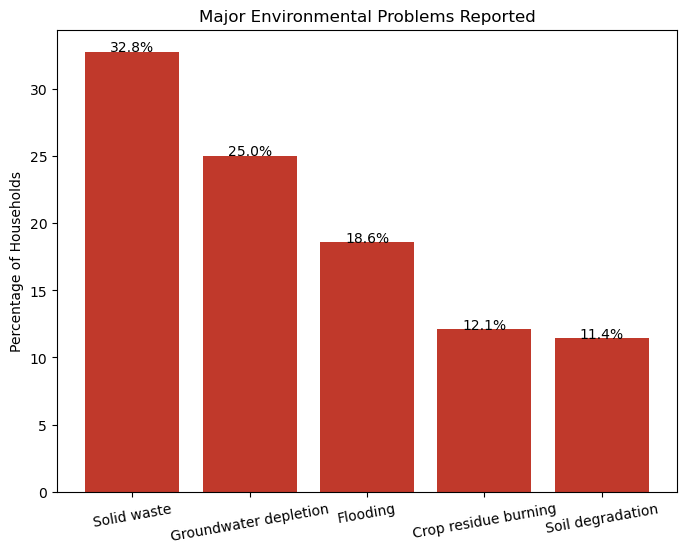

In [89]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_env_stress_counts.index, percentage_env_stress_counts.values, color='#C0392B')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Major Environmental Problems Reported")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=10)
plt.show()

# 2. Renewable Energy Adoption

In [90]:
df['Renewable energy usage'].value_counts()

Renewable energy usage
Solar lights                         180
Biogas                                31
Solar lights, Solar pumps             27
Solar pumps                           20
Solar lights, Solar pumps, Biogas      5
Solar lights, Biogas                   5
Solar lights, None                     5
Biogas, None                           2
Solar pumps, Biogas                    2
Name: count, dtype: int64

In [91]:
renewable = df['Renewable energy usage'].str.split(',').explode().str.strip()

In [92]:
renewable_counts = renewable.value_counts()
renewable_counts

Renewable energy usage
Solar lights    222
Solar pumps      54
Biogas           45
None              7
Name: count, dtype: int64

In [93]:
percentage_renewable_counts = round(renewable.value_counts(normalize=True)*100,2)
percentage_renewable_counts

Renewable energy usage
Solar lights    67.68
Solar pumps     16.46
Biogas          13.72
None             2.13
Name: proportion, dtype: float64

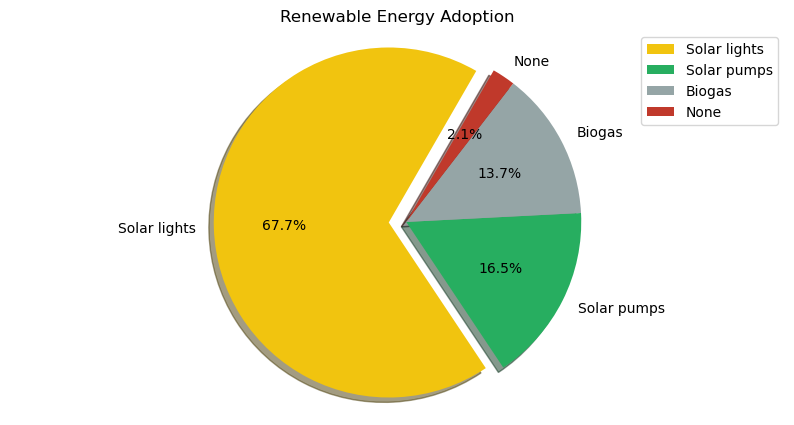

In [94]:
plt.figure(figsize=(10,5))
plt.pie(percentage_renewable_counts.values, labels=percentage_renewable_counts.index, autopct='%1.1f%%', startangle=60, shadow = True,
        colors=['#F1C40F','#27AE60','#95A5A6', '#C0392B'], explode=[0.1,0,0,0])
plt.title("Renewable Energy Adoption")
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

# 3. Disaster Vulnerability Score

In [95]:
df['Disaster vulnerability'].value_counts()

Disaster vulnerability
Flood                       179
Heatwave                     71
Drought                      28
Flood, Heatwave              26
Drought, Heatwave             8
Flood, Drought                7
Flood, None                   6
Heatwave, None                6
Drought, None                 1
Flood, Drought, Heatwave      1
Name: count, dtype: int64

In [96]:
disaster = df['Disaster vulnerability'].str.split(',').explode().str.strip()

In [97]:
disaster_count = disaster.value_counts()
disaster_count

Disaster vulnerability
Flood       219
Heatwave    112
Drought      45
None         13
Name: count, dtype: int64

In [98]:
disaster_percent = round(disaster.value_counts(normalize=True)*100,2)
disaster_percent

Disaster vulnerability
Flood       56.30
Heatwave    28.79
Drought     11.57
None         3.34
Name: proportion, dtype: float64

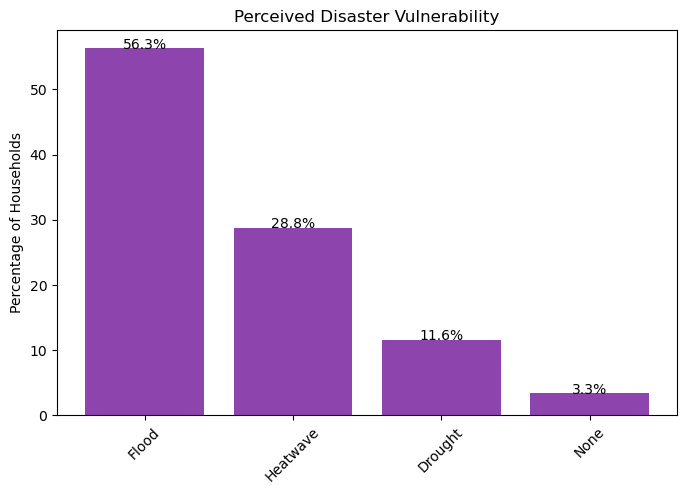

In [99]:
plt.figure(figsize=(8,5))
bars = plt.bar(disaster_percent.index, disaster_percent.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Perceived Disaster Vulnerability")
plt.ylabel("Percentage of Households")
plt.xticks(rotation=45)
plt.show()

# 4. Pond Health Status

In [100]:
pond_condition = df['Condition of pond'].value_counts()
pond_condition

Condition of pond
Highly polluted       376
Partially polluted    301
Clean                 178
Name: count, dtype: int64

In [101]:
pond_percent = round(df['Condition of pond'].value_counts(normalize=True)*100,2)
pond_percent

Condition of pond
Highly polluted       43.98
Partially polluted    35.20
Clean                 20.82
Name: proportion, dtype: float64

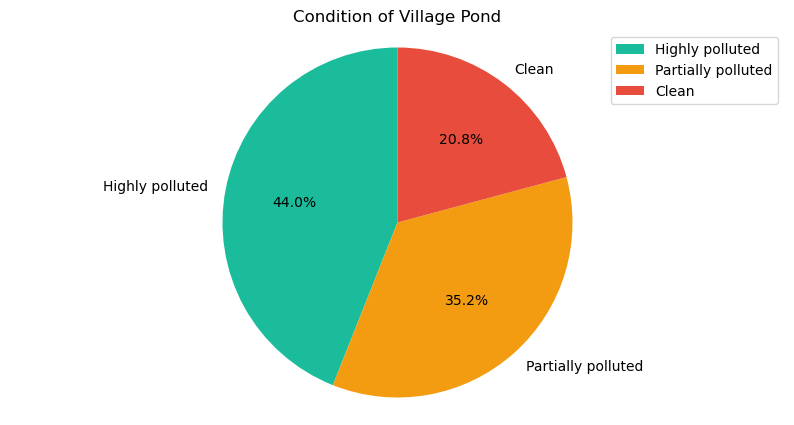

In [102]:
plt.figure(figsize=(10,5))
plt.pie(pond_percent.values, labels=pond_percent.index, autopct='%1.1f%%', colors=['#1ABC9C','#F39C12','#E74C3C'], startangle=90)
plt.title("Condition of Village Pond")
plt.axis('equal')
plt.legend()
plt.show()

# Women Empowerment & Governance Indicators

# Female Labour Force Participation

In [103]:
female_lfp = df['Household women  engaged in income activity'].value_counts()
female_lfp

Household women  engaged in income activity
No     595
Yes    260
Name: count, dtype: int64

In [104]:
percentage_female_lfp = round(df['Household women  engaged in income activity'].value_counts(normalize=True)*100,2)
percentage_female_lfp

Household women  engaged in income activity
No     69.59
Yes    30.41
Name: proportion, dtype: float64

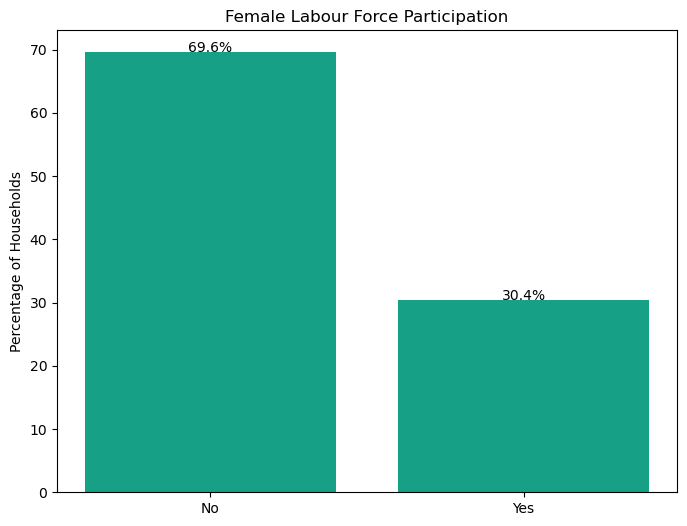

In [105]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_female_lfp.index, percentage_female_lfp.values, color='#16A085')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')

plt.title("Female Labour Force Participation")
plt.ylabel("Percentage of Households")
plt.show()

# Women Bank Account Ownership

In [106]:
women_bank = df['Bank account in woman’s name'].value_counts()
women_bank

Bank account in woman’s name
Yes    653
No     202
Name: count, dtype: int64

In [107]:
percentage_women_bank = round(df['Bank account in woman’s name'].value_counts(normalize=True)*100,2)
percentage_women_bank

Bank account in woman’s name
Yes    76.37
No     23.63
Name: proportion, dtype: float64

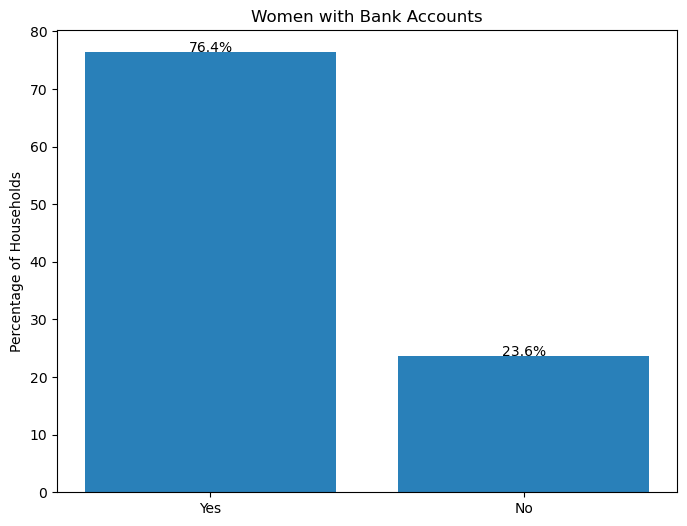

In [108]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_women_bank.index, percentage_women_bank.values, color='#2980B9')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women with Bank Accounts")
plt.ylabel("Percentage of Households")
plt.show()

# SHG Membership

In [109]:
shg = df['SHG membership'].value_counts()
shg

SHG membership
No     745
Yes    110
Name: count, dtype: int64

In [110]:
percentage_shg = round(df['SHG membership'].value_counts(normalize=True)*100,2)
percentage_shg

SHG membership
No     87.13
Yes    12.87
Name: proportion, dtype: float64

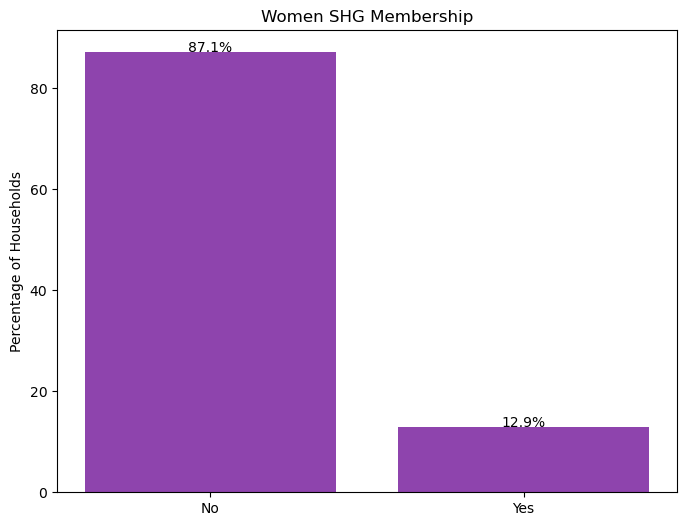

In [111]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_shg.index, percentage_shg.values, color='#8E44AD')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women SHG Membership")
plt.ylabel("Percentage of Households")
plt.show()

# Governance Awareness (Gram Sabha)

In [112]:
gram_sabha = df['Awareness about Gram Sabha meetings'].value_counts()
gram_sabha

Awareness about Gram Sabha meetings
Yes    581
No     274
Name: count, dtype: int64

In [113]:
percentage_gram_sabha = round(df['Awareness about Gram Sabha meetings'].value_counts(normalize=True)*100,2)
percentage_gram_sabha

Awareness about Gram Sabha meetings
Yes    67.95
No     32.05
Name: proportion, dtype: float64

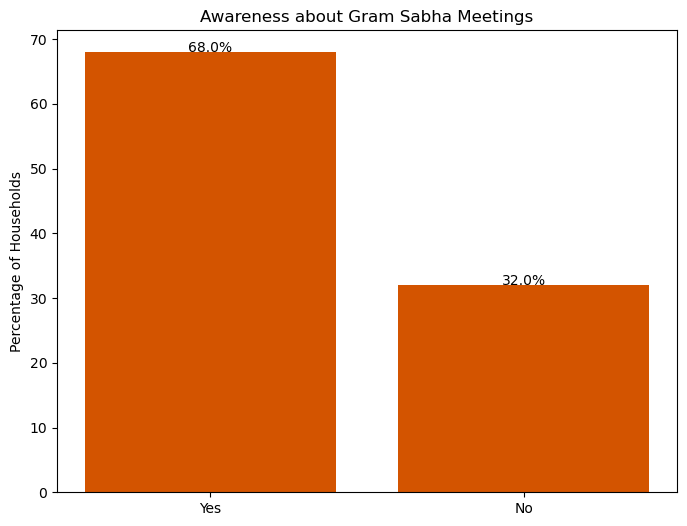

In [114]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_gram_sabha.index, percentage_gram_sabha.values, color='#D35400')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Awareness about Gram Sabha Meetings")
plt.ylabel("Percentage of Households")
plt.show()

# Women Decision-Making Power

In [115]:
decision = df['Role of women in decision-making'].value_counts()
decision

Role of women in decision-making
Moderate    535
High        208
Low         112
Name: count, dtype: int64

In [116]:
percentage_decision = round(df['Role of women in decision-making'].value_counts(normalize=True)*100,2)
percentage_decision

Role of women in decision-making
Moderate    62.57
High        24.33
Low         13.10
Name: proportion, dtype: float64

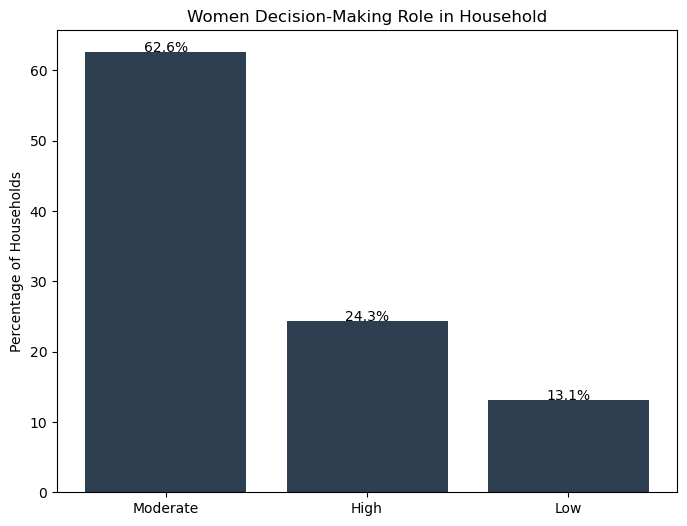

In [117]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_decision.index, percentage_decision.values, color='#2C3E50')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}%",
             ha='center')
plt.title("Women Decision-Making Role in Household")
plt.ylabel("Percentage of Households")
plt.show()

# Strategie Gap Analysis (Qualitative to Quantitative)

# 1. Urgency Index (Most Urgent Village Needs)

In [118]:
print(df['Most urgent need of the village'])

0                                     Road improvements 
1                                       Drainage system 
2                                            Healthcare 
3           Transport, Dispensary and pond purification 
4      All good there is gym in village,school ,every...
                             ...                        
850                                           dispensary
851    The village faces many problems like no high s...
852                           Transportation and health 
853                                             Nothing 
854    The village has problems like no high school, ...
Name: Most urgent need of the village, Length: 855, dtype: object


In [119]:
urgency = df['Most urgent need of the village'].value_counts()
urgency

Most urgent need of the village
Hospital                                                                                                                                                       28
Employment                                                                                                                                                     18
Education                                                                                                                                                      15
Roads                                                                                                                                                          13
Health                                                                                                                                                         12
                                                                                                                                                              

In [120]:
urgency.count()

np.int64(547)

In [121]:
urgency = df['Most urgent need of the village'].str.lower().str.strip()
urgency

0                                      road improvements
1                                        drainage system
2                                             healthcare
3            transport, dispensary and pond purification
4      all good there is gym in village,school ,every...
                             ...                        
850                                           dispensary
851    the village faces many problems like no high s...
852                            transportation and health
853                                              nothing
854    the village has problems like no high school, ...
Name: Most urgent need of the village, Length: 855, dtype: object

In [122]:
urgency_split = urgency.str.split(r'[,.]').explode().str.strip()
urgency_split

0                     road improvements
1                       drainage system
2                            healthcare
3                             transport
3      dispensary and pond purification
                     ...               
854     and floods due to poor drainage
854       these issues affect education
854                              travel
854                      and daily life
854                                    
Name: Most urgent need of the village, Length: 1024, dtype: object

In [123]:
urgency_split = urgency_split.replace('', pd.NA).dropna()
urgency_split

0                     road improvements
1                       drainage system
2                            healthcare
3                             transport
3      dispensary and pond purification
                     ...               
854                           few buses
854     and floods due to poor drainage
854       these issues affect education
854                              travel
854                      and daily life
Name: Most urgent need of the village, Length: 968, dtype: object

In [124]:
urgency_values = urgency_split.value_counts()
urgency_values.head(10)

Most urgent need of the village
hospital            43
education           32
employment          29
waste management    22
health              20
roads               19
drainage system     17
dispensary          16
water               15
transport           14
Name: count, dtype: int64

In [125]:
category_map = {
    "hospital":"health",
    "hospitals":"health",
    "healthcare":"health",
    "health center":"health",
    "health facilities":"health",
    "medical":"health",
    "dispensary":"health",
    
    "roads":"roads",
    "road":"roads",
    "better roads":"roads",
    "road repair":"roads",
    "road development":"roads",
    "roads development":"roads",
    "good roads":"roads",
    
    "drainage":"sanitation",
    "drainage system":"sanitation",
    "sewage":"sanitation",
    "sewerage":"sanitation",
    "sewerage system":"sanitation",
    "sewage system":"sanitation",
    "severage":"sanitation",
    "waste management":"sanitation",
    "waste water treatment":"sanitation",
    
    "water":"water",
    "clean water":"water",
    "water supply":"water",
    "water management":"water",
    
    "school":"education",
    "education services":"education",
    
    "transport":"transport",
    "travelling":"transport",
    
    "cleaning":"cleanliness",
    "cleanliness":"cleanliness",
    "cleanness":"cleanliness"}

In [126]:
urgency_clean = urgency_split.replace(category_map)
urgency_summary = urgency_clean.value_counts()
urgency_summary.head(10)

Most urgent need of the village
health           104
sanitation        91
roads             57
education         44
employment        29
water             26
transport         18
cleanliness       17
pond cleaning     11
no                 9
Name: count, dtype: int64

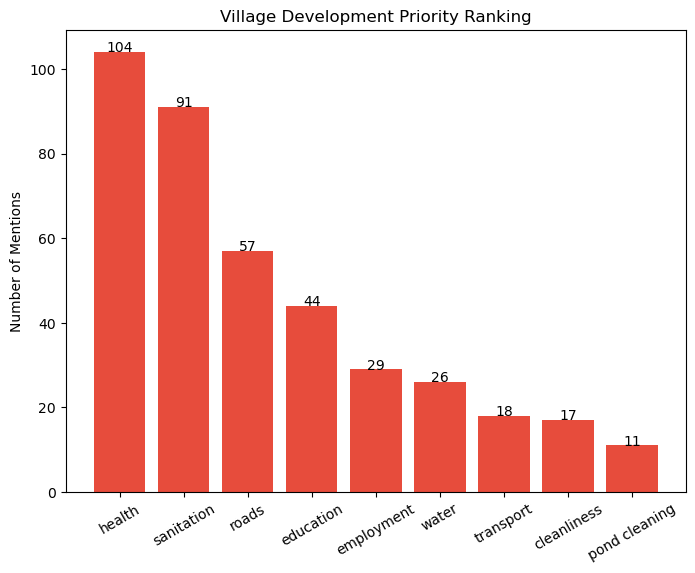

In [127]:
plt.figure(figsize=(8,6))
bars = plt.bar(urgency_summary.head(9).index, urgency_summary.head(9).values, color='#E74C3C')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()}",
             ha='center')
plt.title("Village Development Priority Ranking")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=30)
plt.show()

# 2. Skill Gap Analysis

In [128]:
skill_trained = df['Skill-trained member in household'].value_counts()
skill_trained

Skill-trained member in household
Yes    538
No     317
Name: count, dtype: int64

In [129]:
percentage_skill_trained = round(df['Skill-trained member in household'].value_counts(normalize=True)*100,2)
percentage_skill_trained

Skill-trained member in household
Yes    62.92
No     37.08
Name: proportion, dtype: float64

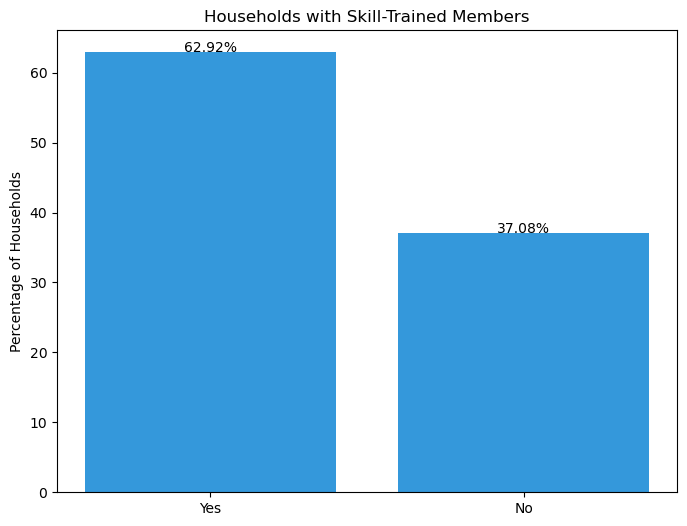

In [130]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skill_trained.index, percentage_skill_trained.values, color='#3498DB')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Households with Skill-Trained Members")
plt.ylabel("Percentage of Households")
plt.show()

In [131]:
df['Skills required'].value_counts()

Skills required
Agriculture                                              313
Computer                                                 117
Tailoring                                                 81
Driving                                                   54
Agriculture, Tailoring                                    37
Computer, Electrical                                      27
Electrical                                                22
Agriculture, Driving                                      22
Tailoring, Computer                                       19
Agriculture, Tailoring, Computer, Electrical, Driving     18
Agriculture, Computer                                     18
Tailoring, Computer, Electrical                           13
Computer, Electrical, Driving                             11
Agriculture, Tailoring, Computer                          11
Computer, Driving                                         11
Agriculture, Tailoring, Driving                           10
Agricult

In [132]:
skills_required = df['Skills required'].str.split(',').explode().str.strip()

In [133]:
skills_required_counts = skills_required.value_counts()
skills_required_counts

Skills required
Agriculture    476
Computer       280
Tailoring      225
Driving        174
Electrical     144
Name: count, dtype: int64

In [134]:
percentage_skills_required = round(skills_required.value_counts(normalize=True)*100,2)
percentage_skills_required

Skills required
Agriculture    36.64
Computer       21.56
Tailoring      17.32
Driving        13.39
Electrical     11.09
Name: proportion, dtype: float64

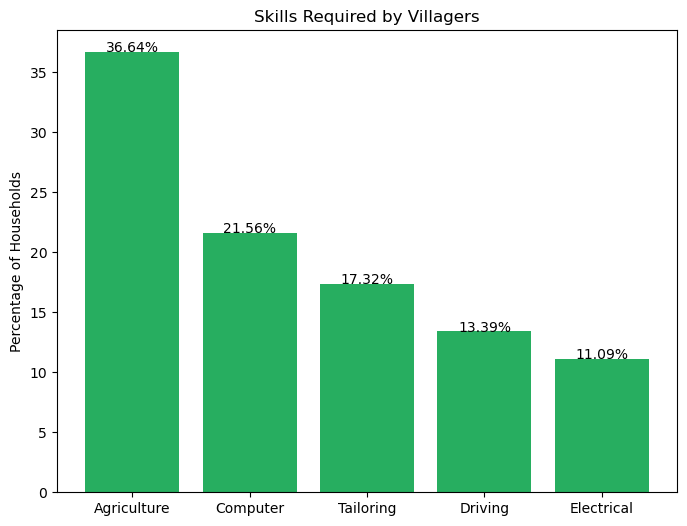

In [135]:
plt.figure(figsize=(8,6))
bars = plt.bar(percentage_skills_required.index, percentage_skills_required.values, color='#27AE60')
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}%",
             ha='center')
plt.title("Skills Required by Villagers")
plt.ylabel("Percentage of Households")
plt.show()

# A. Poverty–Education–Migration Cycle Analysis

# 1. Income vs School Dropout (Poverty → Education)

In [136]:
income_dropout = pd.crosstab(df['Approx. Annual Household Income'], df['School dropout cases  in the household'], normalize='index') * 100
income_dropout

School dropout cases in the household,NO,Partia,YES
Approx. Annual Household Income,,,
<1 lakh,75.000000,5.281690,19.718310
1-3 lakh,78.694158,5.841924,15.463918
3-5 lakh,84.180791,6.779661,9.039548
>5 lakh,85.436893,3.883495,10.679612


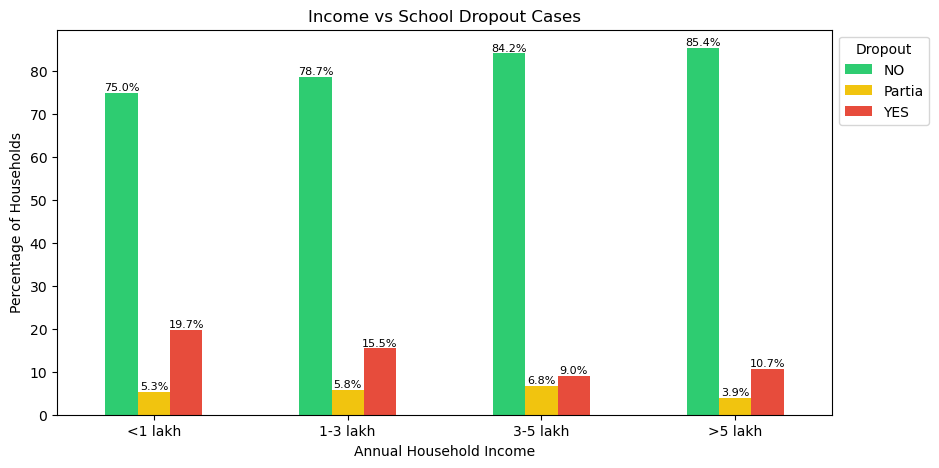

In [137]:
bars = income_dropout.plot(kind='bar', figsize=(10,5), color=['#2ECC71','#F1C40F','#E74C3C'])
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.1f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Income vs School Dropout Cases")
plt.ylabel("Percentage of Households")
plt.xlabel("Annual Household Income")
plt.xticks(rotation=0)
plt.legend(title="Dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Migration vs Reason for Dropout (Drivers)

In [138]:
migration_dropout_reason = round(pd.crosstab(df['Migration for employment'], df['Reason for dropout'], normalize='index') * 100,2)
migration_dropout_reason

Reason for dropout,Domestic work,"Domestic work, Lack of interest",Financial,"Financial, Domestic work","Financial, Domestic work, Lack of interest","Financial, Lack of interest","Financial, Migration",Lack of interest,Migration
Migration for employment,,,,,,,,,
Permanent,17.81,1.37,31.51,4.11,0.00,0.00,4.11,16.44,24.66
Seasonal,20.83,0.00,32.29,4.17,1.04,1.04,2.08,29.17,9.38


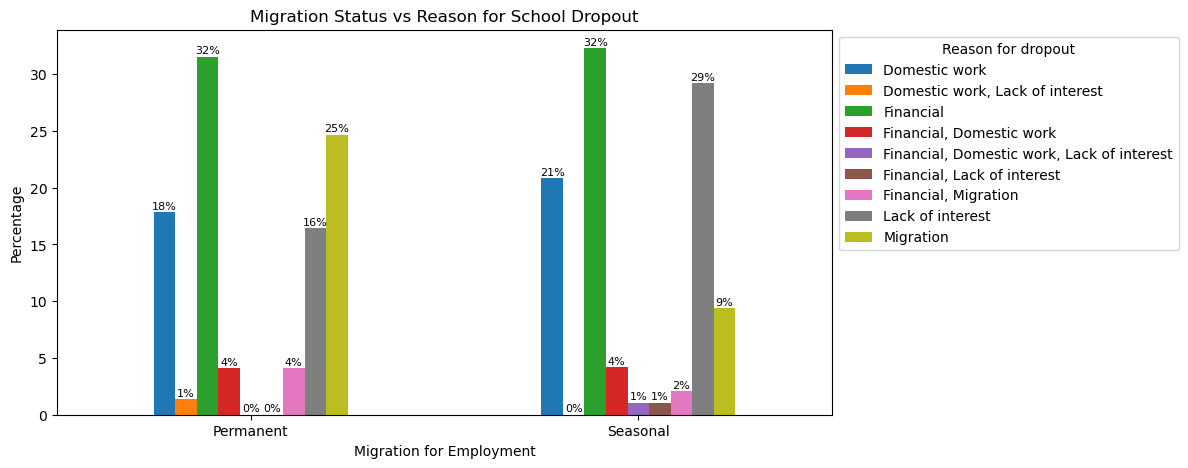

In [139]:
bars = migration_dropout_reason.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.0f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Migration Status vs Reason for School Dropout")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.xticks(rotation=0)
plt.legend(title="Reason for dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Literacy vs Migration (Outcome)

In [140]:
literacy_migration = round(pd.crosstab(df['Literacy status of household'], df['Migration for employment'], normalize='index') * 100,2)
literacy_migration

Migration for employment,Permanent,Seasonal
Literacy status of household,,
All literate,45.81,54.19
Mostly illiterate,28.57,71.43
Partially literate,36.87,63.13


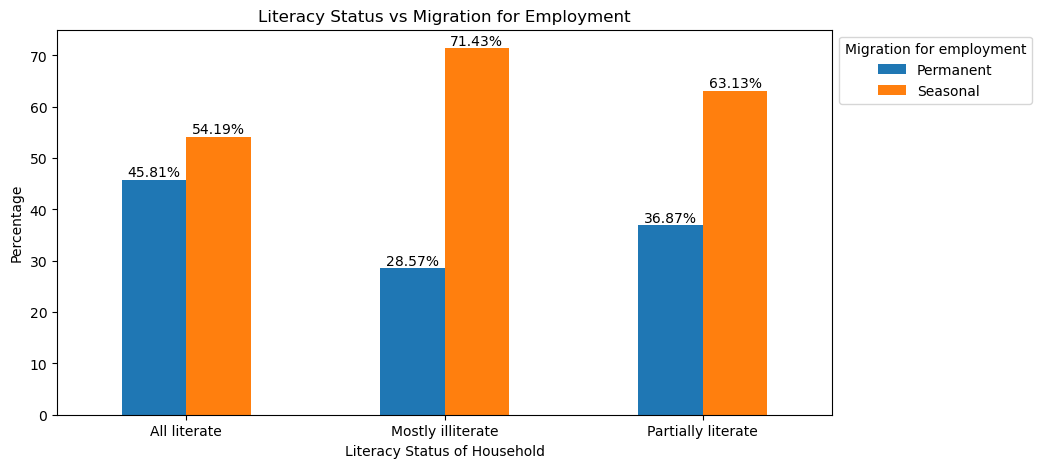

In [141]:
bars = literacy_migration.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}%',
             ha='center',
             va='bottom')
plt.title("Literacy Status vs Migration for Employment")
plt.ylabel("Percentage")
plt.xlabel("Literacy Status of Household")
plt.xticks(rotation=0)
plt.legend(title="Migration for employment", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [142]:
round(pd.crosstab([df['Approx. Annual Household Income'], df['Migration for employment']], df['School dropout cases  in the household'], 
            normalize='index') * 100, 2)

School dropout cases  in the household                       NO  Partia    YES
Approx. Annual Household Income Migration for employment                      
<1 lakh                         Permanent                 71.43    3.57  25.00
                                Seasonal                  66.28    6.98  26.74
1-3 lakh                        Permanent                 70.97   12.90  16.13
                                Seasonal                  76.92    1.28  21.79
3-5 lakh                        Permanent                 68.75   18.75  12.50
                                Seasonal                  76.47    5.88  17.65
>5 lakh                         Permanent                 73.91    4.35  21.74
                                Seasonal                  84.21   15.79   0.00

# Social Equity in Public Service Delivery

# 1. Health Access Inequality

# Social Category vs Type of Health Facility Used

In [143]:
health_access = round(pd.crosstab(df['Social Category'], df['Type of facility used'], normalize='index') * 100,2)
health_access

Type of facility used,CHC,PHC,Private,Sub-Centre
Social Category,,,,
General,4.14,31.47,34.78,29.61
OBC,9.33,30.00,30.00,30.67
Scheduled Caste,8.61,24.88,33.49,33.01
Scheduled Tribe,7.69,53.85,0.00,38.46


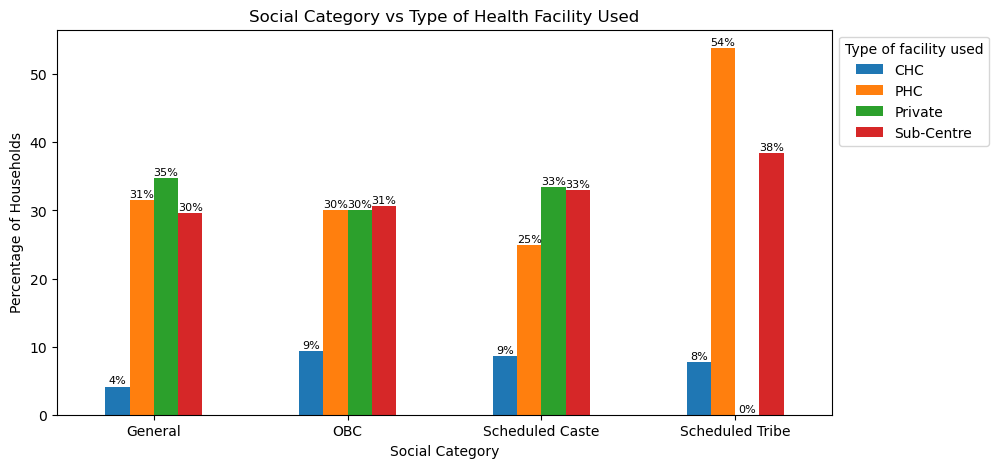

In [144]:
bars = health_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs Type of Health Facility Used")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs ASHA/ANM Visits

In [145]:
asha_visits = round(pd.crosstab(df['Social Category'], df['ASHA/ANM visit'], normalize='index') * 100, 2)
asha_visits

ASHA/ANM visit,Never,Occasional,Regular
Social Category,,,
General,20.70,49.48,29.81
OBC,19.33,48.67,32.00
Scheduled Caste,19.14,45.93,34.93
Scheduled Tribe,38.46,30.77,30.77


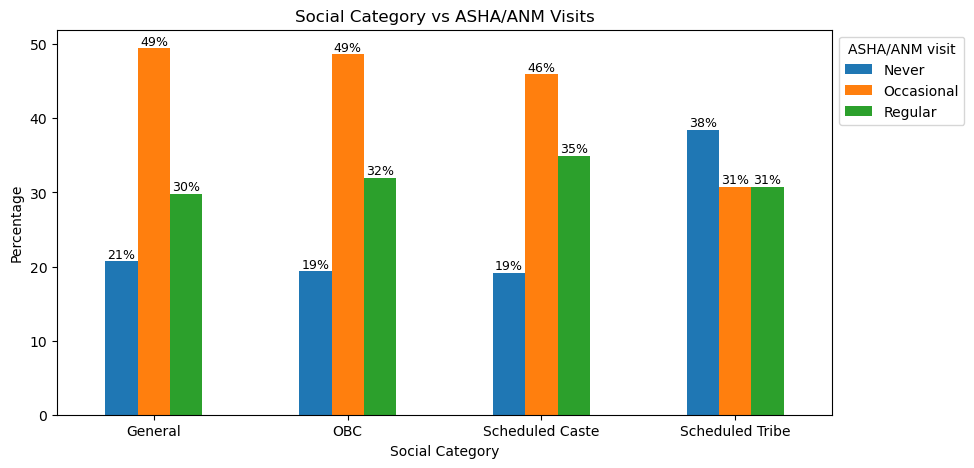

In [146]:
bars = asha_visits.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=9)
plt.title("Social Category vs ASHA/ANM Visits")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="ASHA/ANM visit", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Scheme Reach (Equity in Government Benefits)

# Social Category vs PM-JAY (Ayushman Bharat)

In [147]:
pmjay_access = round(pd.crosstab(df['Social Category'], df['Health Schemes   [Ayushman Bharat (PM-JAY)]'], normalize='index') * 100, 2)
pmjay_access

Health Schemes [Ayushman Bharat (PM-JAY)],Applied,Availed,Aware,Not aware
Social Category,,,,
General,8.90,10.97,44.93,35.20
OBC,10.00,8.67,51.33,30.00
Scheduled Caste,8.61,10.05,46.41,34.93
Scheduled Tribe,0.00,0.00,76.92,23.08


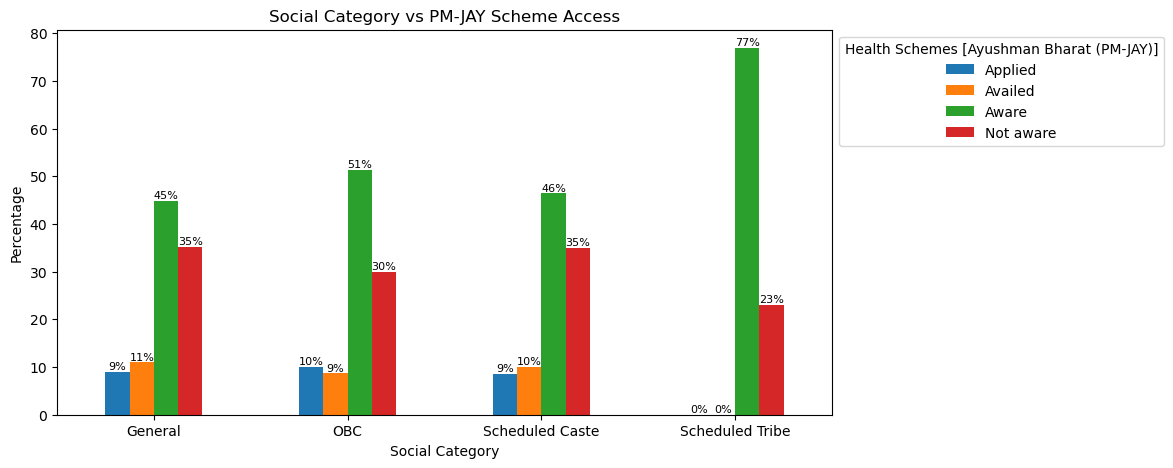

In [148]:
bars = pmjay_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs PM-JAY Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Health Schemes [Ayushman Bharat (PM-JAY)]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Social Category vs MGNREGA

In [149]:
mgnrega_access = round(pd.crosstab(df['Social Category'], df['Livelihood Schemes   [MGNREGA]'], normalize='index') * 100, 2)
mgnrega_access

Livelihood Schemes [MGNREGA],Applied,Availed,Aware,Not Aware
Social Category,,,,
General,3.52,4.35,50.72,41.41
OBC,4.00,5.33,59.33,31.33
Scheduled Caste,4.31,7.66,53.11,34.93
Scheduled Tribe,7.69,0.00,69.23,23.08


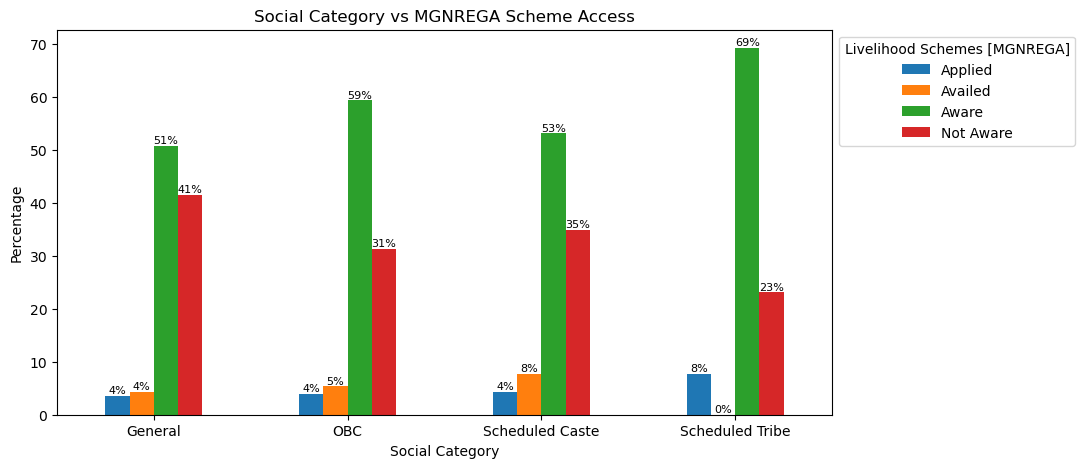

In [150]:
bars = mgnrega_access.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Social Category vs MGNREGA Scheme Access")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Livelihood Schemes [MGNREGA]", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Digital Divide Analysis

# Social Category vs Access to Digital Devices

In [151]:
digital_divide = round(pd.crosstab(df['Social Category'], df['Access to digital devices'], normalize='index') * 100, 2)
digital_divide

Access to digital devices,Laptop,Smartphone,"Smartphone, Laptop","Smartphone, None"
Social Category,,,,
General,3.25,69.20,27.11,0.43
OBC,2.14,75.71,22.14,0.00
Scheduled Caste,1.04,85.42,13.54,0.00
Scheduled Tribe,8.33,83.33,8.33,0.00


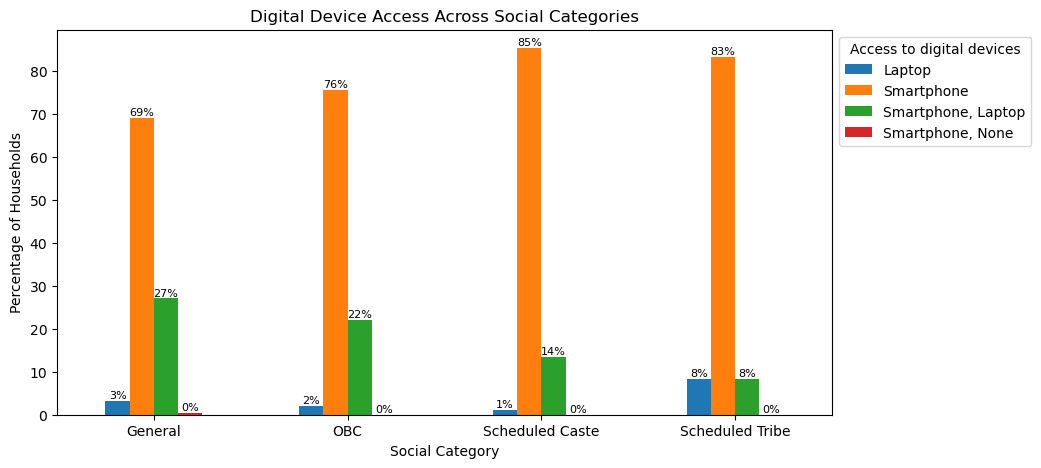

In [152]:
bars = digital_divide.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Digital Device Access Across Social Categories")
plt.ylabel("Percentage of Households")
plt.xlabel("Social Category")
plt.xticks(rotation=0)
plt.legend(title="Access to digital devices", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Women's Economic Agency vs. Decision-Making Power

# 1. Income Activity vs Decision-Making Power

In [153]:
decision_income = round(pd.crosstab(df['Household women  engaged in income activity'], df['Role of women in decision-making'], normalize='index') 
                        * 100, 2)
decision_income

Role of women in decision-making,High,Low,Moderate
Household women engaged in income activity,,,
No,19.16,15.80,65.04
Yes,36.15,6.92,56.92


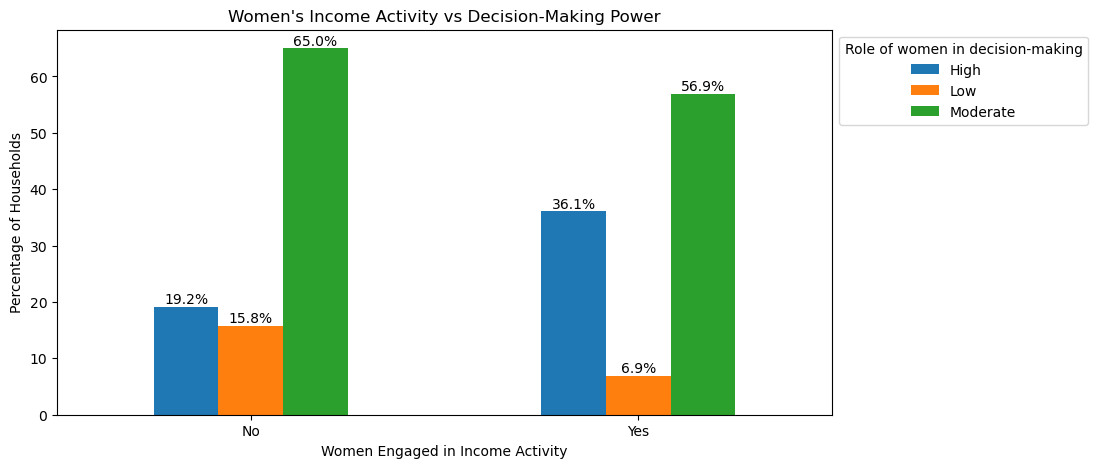

In [154]:
bars = decision_income.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Women's Income Activity vs Decision-Making Power")
plt.ylabel("Percentage of Households")
plt.xlabel("Women Engaged in Income Activity")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. SHG Membership vs Decision-Making Power

In [155]:
shg_decision = round(pd.crosstab(df['SHG membership'], df['Role of women in decision-making'], normalize='index') * 100, 2)
shg_decision

Role of women in decision-making,High,Low,Moderate
SHG membership,,,
No,21.48,14.63,63.89
Yes,43.64,2.73,53.64


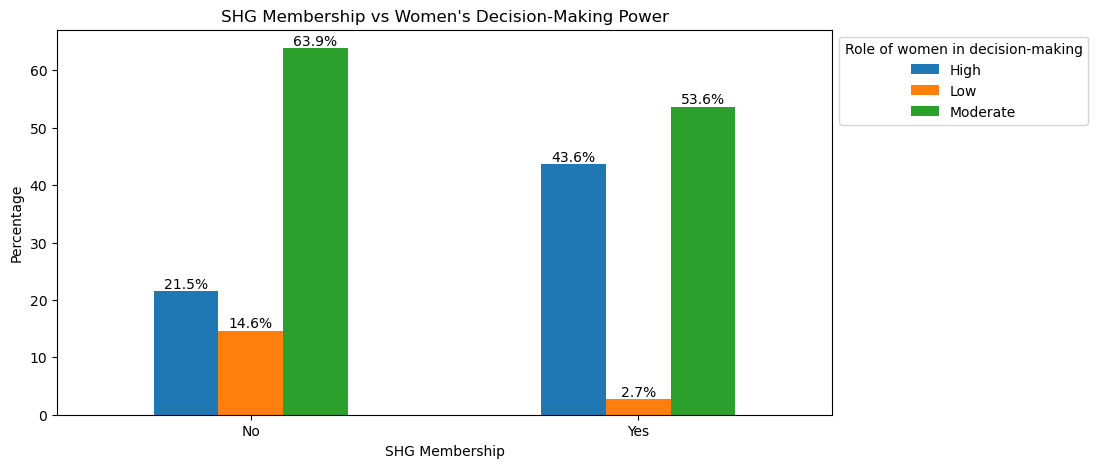

In [156]:
bars = shg_decision.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("SHG Membership vs Women's Decision-Making Power")
plt.ylabel("Percentage")
plt.xlabel("SHG Membership")
plt.xticks(rotation=0)
plt.legend(title="Role of women in decision-making", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. SHG Membership vs Awareness of Women Schemes

In [157]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [NRLM]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [NRLM],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,2.28,2.42,29.53,65.77
Yes,3.64,3.64,32.73,60.00


In [158]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Pradhan Mantri Matru Vandana Yojana]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Pradhan Mantri Matru Vandana Yojana],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,2.15,2.01,39.06,56.78
Yes,5.45,1.82,45.45,47.27


In [159]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Beti Bachao Beti Padhao]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Beti Bachao Beti Padhao],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,4.56,3.76,60.27,31.41
Yes,15.45,3.64,59.09,21.82


In [160]:
shg_scheme = round(pd.crosstab(df['SHG membership'], df['Women Schemes   [Sukanya Samriddhi]'], normalize='index') * 100, 2)
shg_scheme

Women Schemes [Sukanya Samriddhi],Applied,Availed,Aware,Not Aware
SHG membership,,,,
No,3.89,2.42,37.72,55.97
Yes,4.55,6.36,46.36,42.73


# Health Outcomes and Environmental Sanitation

# 1. Environmental Link

In [161]:
pond_disease = round(pd.crosstab( df['Condition of pond'], df['Common diseases'], normalize='index') * 100,2)
pond_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, None","BP, Diabetes, Respiratory","BP, Diabetes, TB","BP, Diabetes, TB, Respiratory","BP, None","BP, Respiratory","BP, TB","BP, TB, Respiratory",Diabetes,"Diabetes, None","Diabetes, Respiratory","Diabetes, TB",Respiratory,TB,"TB, None","TB, Respiratory"
Condition of pond,,,,,,,,,,,,,,,,,,
Clean,42.47,13.70,0.00,0.00,1.37,0.00,2.74,1.37,0.00,0.00,26.03,0.00,1.37,0.00,8.22,1.37,0.00,1.37
Highly polluted,42.08,25.14,0.00,6.01,1.09,0.55,1.09,3.28,1.09,0.55,16.39,1.64,0.00,0.00,0.55,0.55,0.00,0.00
Partially polluted,36.59,28.66,0.61,4.27,0.00,0.61,1.83,1.83,0.61,1.22,19.51,0.00,0.00,0.61,2.44,0.61,0.61,0.00


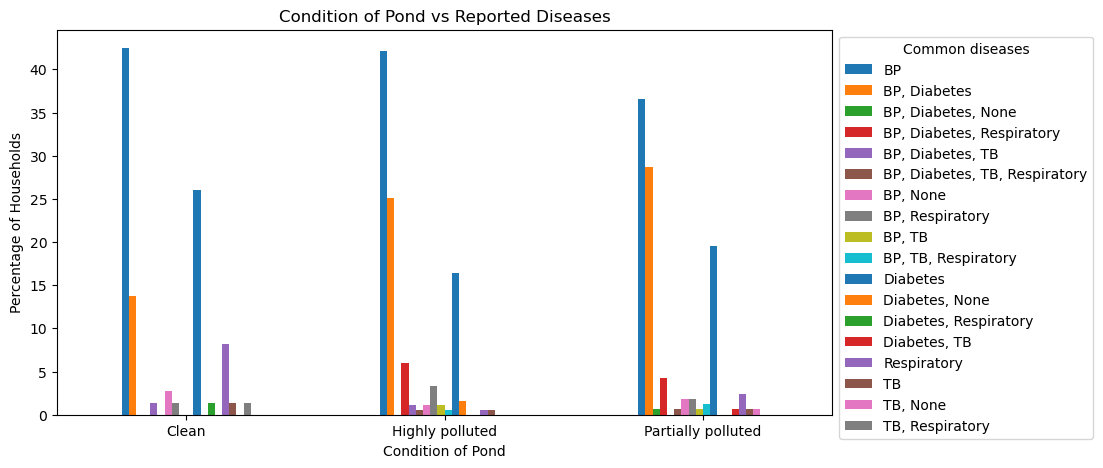

In [162]:
pond_disease.plot(kind='bar', figsize=(10,5))
plt.title("Condition of Pond vs Reported Diseases")
plt.ylabel("Percentage of Households")
plt.xlabel("Condition of Pond")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 2. Solid Waste Disposal vs Diseases

In [163]:
waste_disease = round(pd.crosstab(df['Solid waste disposal method'], df['Common diseases'], normalize='index') * 100, 2)
waste_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, None","BP, Diabetes, Respiratory","BP, Diabetes, TB","BP, Diabetes, TB, Respiratory","BP, None","BP, Respiratory","BP, TB","BP, TB, Respiratory",Diabetes,"Diabetes, None","Diabetes, Respiratory","Diabetes, TB",Respiratory,TB,"TB, None","TB, Respiratory"
Solid waste disposal method,,,,,,,,,,,,,,,,,,
Burning,46.67,13.33,0.00,6.67,0.00,6.67,0.00,0.00,6.67,6.67,13.33,0.00,0.00,0.0,0.00,0.00,0.00,0.00
Door-to-door,41.44,22.65,0.55,2.76,0.55,0.55,1.66,2.76,0.00,0.00,19.89,1.10,0.55,0.0,4.97,0.55,0.00,0.00
"Door-to-door, Open dumping",25.00,12.50,0.00,0.00,0.00,0.00,0.00,0.00,12.50,12.50,25.00,0.00,0.00,12.5,0.00,0.00,0.00,0.00
Open dumping,38.02,26.56,0.00,5.73,1.04,0.00,2.08,2.60,0.52,0.52,19.27,0.52,0.00,0.0,1.04,1.04,0.52,0.52
"Open dumping, Burning",45.83,33.33,0.00,4.17,0.00,0.00,0.00,0.00,0.00,0.00,16.67,0.00,0.00,0.0,0.00,0.00,0.00,0.00


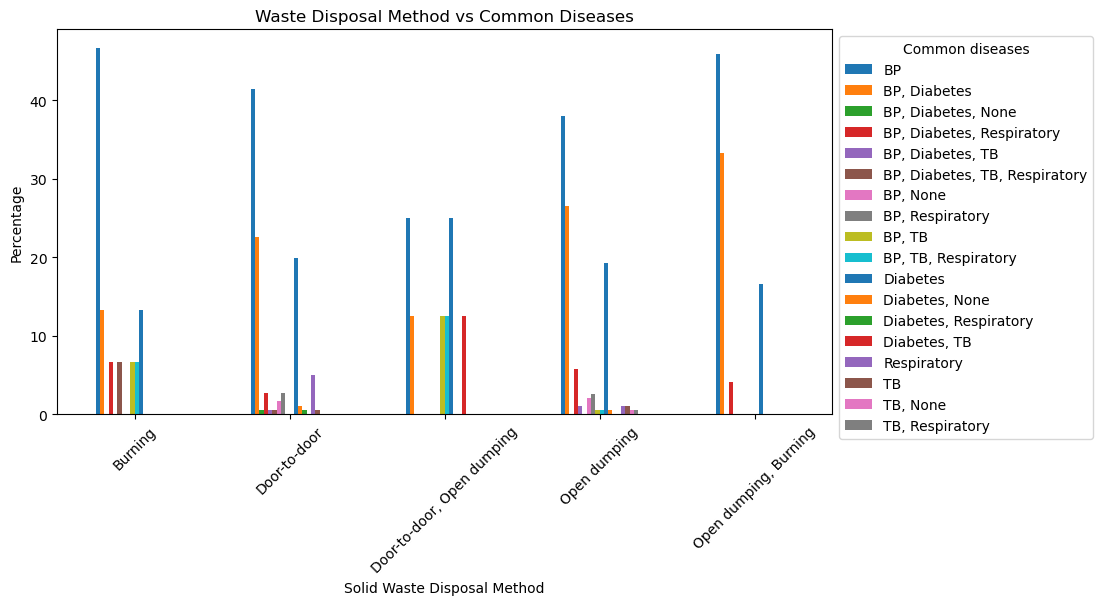

In [164]:
waste_disease.plot(kind='bar', figsize=(10,5))
plt.title("Waste Disposal Method vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Solid Waste Disposal Method")
plt.xticks(rotation=45)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# 3. Hygiene Practices vs Diseases

In [165]:
handwash_disease = round(pd.crosstab(df['Handwashing with soap'], df['Common diseases'], normalize='index') * 100, 2)
handwash_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, None","BP, Diabetes, Respiratory","BP, Diabetes, TB","BP, Diabetes, TB, Respiratory","BP, None","BP, Respiratory","BP, TB","BP, TB, Respiratory",Diabetes,"Diabetes, None","Diabetes, Respiratory","Diabetes, TB",Respiratory,TB,"TB, None","TB, Respiratory"
Handwashing with soap,,,,,,,,,,,,,,,,,,
Always,43.21,22.22,0.31,3.40,0.31,0.31,1.85,2.16,0.62,0.62,19.14,0.93,0.31,0.31,2.78,0.93,0.31,0.31
Rarely,33.33,25.00,0.00,0.00,16.67,0.00,0.00,0.00,8.33,0.00,16.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sometimes,28.57,33.33,0.00,8.33,0.00,1.19,1.19,3.57,0.00,1.19,20.24,0.00,0.00,0.00,2.38,0.00,0.00,0.00


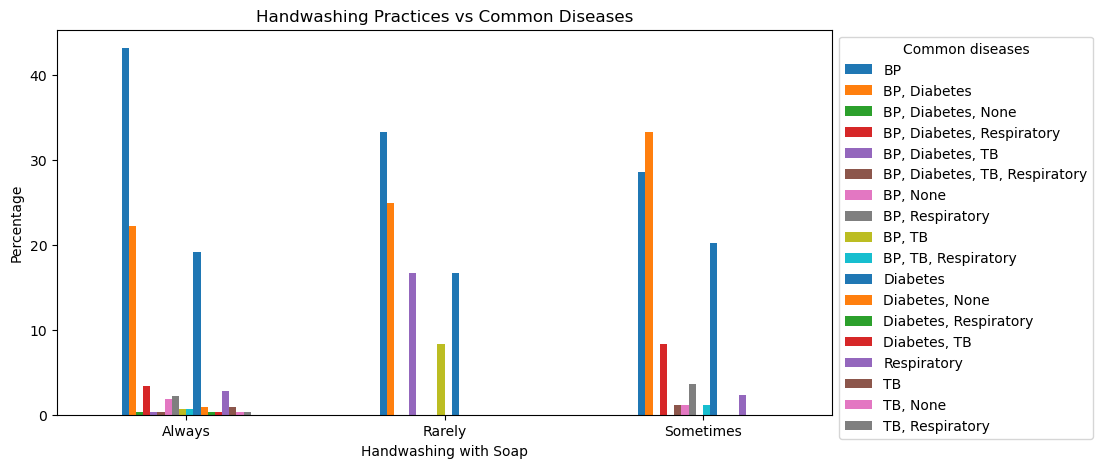

In [166]:
handwash_disease.plot(kind='bar', figsize=(10,5))
plt.title("Handwashing Practices vs Common Diseases")
plt.ylabel("Percentage")
plt.xlabel("Handwashing with Soap")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [167]:
toilet_disease = round(pd.crosstab(df['Toilet availability'], df['Common diseases'], normalize='index') * 100, 2)
toilet_disease

Common diseases,BP,"BP, Diabetes","BP, Diabetes, None","BP, Diabetes, Respiratory","BP, Diabetes, TB","BP, Diabetes, TB, Respiratory","BP, None","BP, Respiratory","BP, TB","BP, TB, Respiratory",Diabetes,"Diabetes, None","Diabetes, Respiratory","Diabetes, TB",Respiratory,TB,"TB, None","TB, Respiratory"
Toilet availability,,,,,,,,,,,,,,,,,,
NO,25.00,37.50,0.00,6.25,6.25,0.0,0.00,0.00,0.00,0.00,25.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
YES,40.59,24.01,0.25,4.21,0.50,0.5,1.73,2.48,0.74,0.74,19.06,0.74,0.25,0.25,2.72,0.74,0.25,0.25


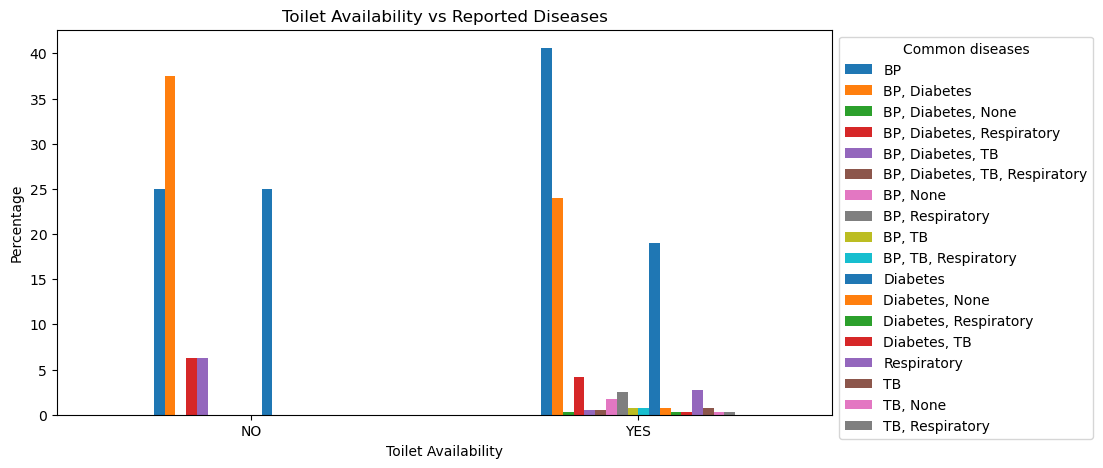

In [168]:
toilet_disease.plot(kind='bar', figsize=(10,5))
plt.title("Toilet Availability vs Reported Diseases")
plt.ylabel("Percentage")
plt.xlabel("Toilet Availability")
plt.xticks(rotation=0)
plt.legend(title="Common diseases", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

# Infrastructure Accessibility & Service Utilization

# 1. Distance to Health Facility vs Immunization Status

In [169]:
health_distance_immunization = round(pd.crosstab(df['Distance to nearest health facility'], df['Immunization status of children (0-5)'], 
                                                 normalize='index') * 100, 2)
health_distance_immunization

Immunization status of children (0-5),Fully,Not immunised,Partially
Distance to nearest health facility,,,
1-5 km,71.85,8.31,19.84
<1 km,74.44,14.35,11.21
>5 km,69.50,12.74,17.76


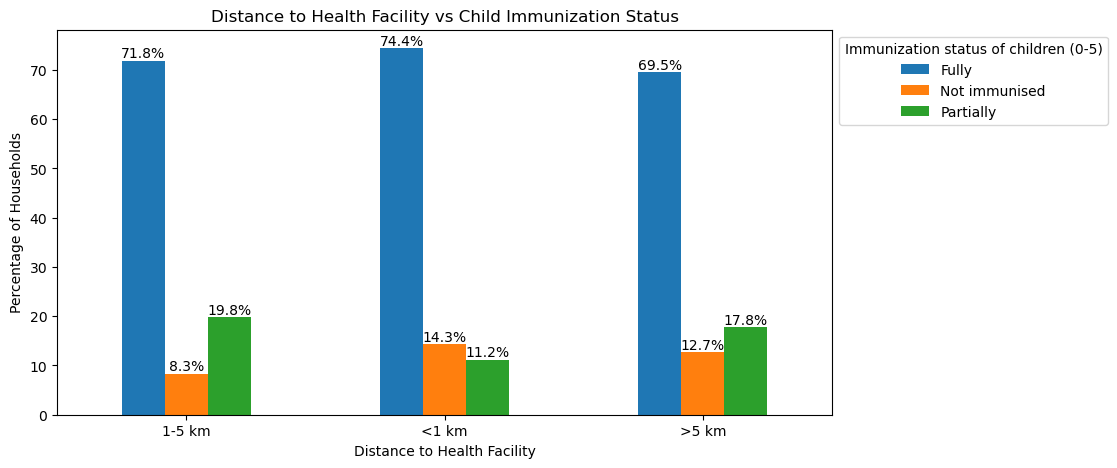

In [170]:
bars = health_distance_immunization.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Child Immunization Status")
plt.ylabel("Percentage of Households")
plt.xlabel("Distance to Health Facility")
plt.legend(title='Immunization status of children (0-5)', bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Distance to School vs Girls' Education

In [171]:
school_distance_girls = round(pd.crosstab(df['Distance to nearest school'], df['Girls continuing education beyond Class X'], normalize='index') 
                              * 100, 2)
school_distance_girls

Girls continuing education beyond Class X,No,YES
Distance to nearest school,,
1-3 km,20.70,79.30
<1 km,26.96,73.04
>3 km,32.44,67.56


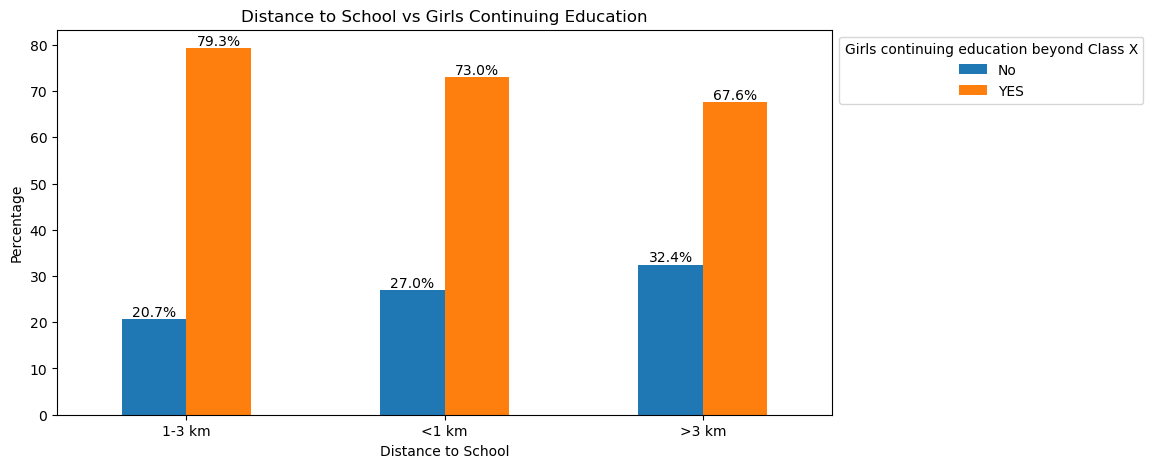

In [172]:
bars = school_distance_girls.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Distance to School vs Girls Continuing Education")
plt.ylabel("Percentage")
plt.xlabel("Distance to School")
plt.legend(title="Girls continuing education beyond Class X", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Behavioral Shift in Healthcare Choice

In [173]:
distance_facility_type = round(pd.crosstab(df['Distance to nearest health facility'], df['Type of facility used'], normalize='index') * 100, 2)
distance_facility_type

Type of facility used,CHC,PHC,Private,Sub-Centre
Distance to nearest health facility,,,,
1-5 km,8.31,45.58,28.42,17.69
<1 km,6.28,21.08,21.08,51.57
>5 km,3.09,15.06,50.19,31.66


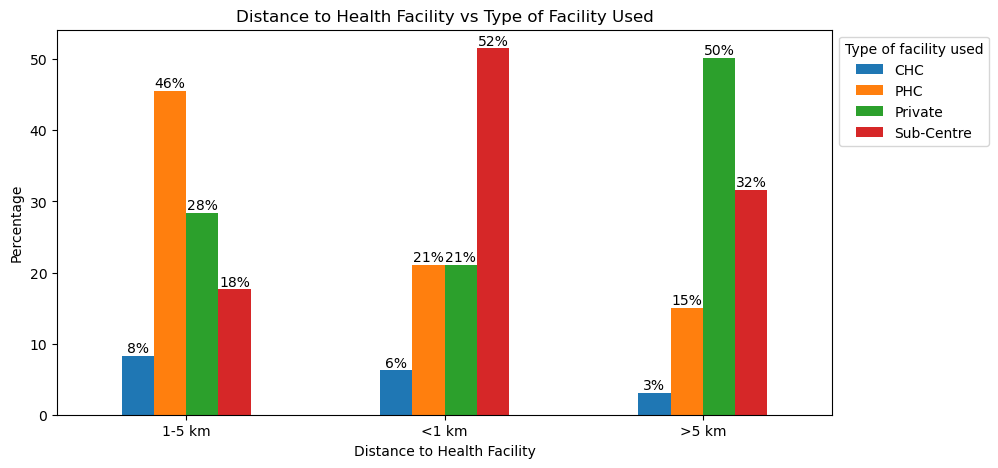

In [174]:
bars = distance_facility_type.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Distance to Health Facility vs Type of Facility Used")
plt.ylabel("Percentage")
plt.xlabel("Distance to Health Facility")
plt.legend(title="Type of facility used", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Village Governance & Civic Engagement

# 1. Knowledge–Action Gap

In [175]:
awareness_participation = round(pd.crosstab(df['Awareness about Gram Sabha meetings'], df['Participation in village development'], normalize='index')
                                * 100, 2)
awareness_participation

Participation in village development,Never,Occasional,Regular
Awareness about Gram Sabha meetings,,,
No,54.74,37.59,7.66
Yes,14.97,46.82,38.21


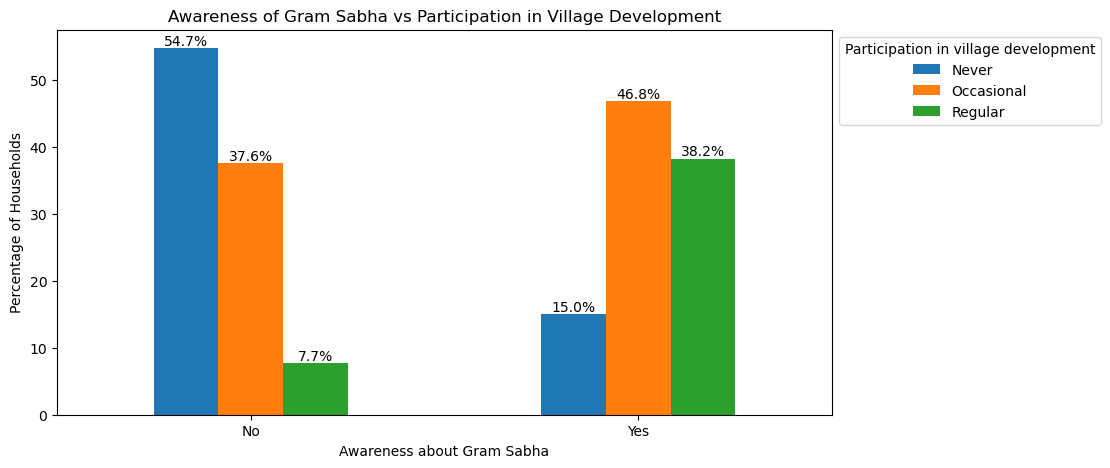

In [176]:
bars = awareness_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Awareness of Gram Sabha vs Participation in Village Development")
plt.ylabel("Percentage of Households")
plt.xlabel("Awareness about Gram Sabha")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 2. Migration vs Participation

In [177]:
migration_participation = round(pd.crosstab(df['Migration for employment'], df['Participation in village development'], normalize='index') * 100, 2)
migration_participation

Participation in village development,Never,Occasional,Regular
Migration for employment,,,
Permanent,28.97,40.00,31.03
Seasonal,17.97,45.62,36.41


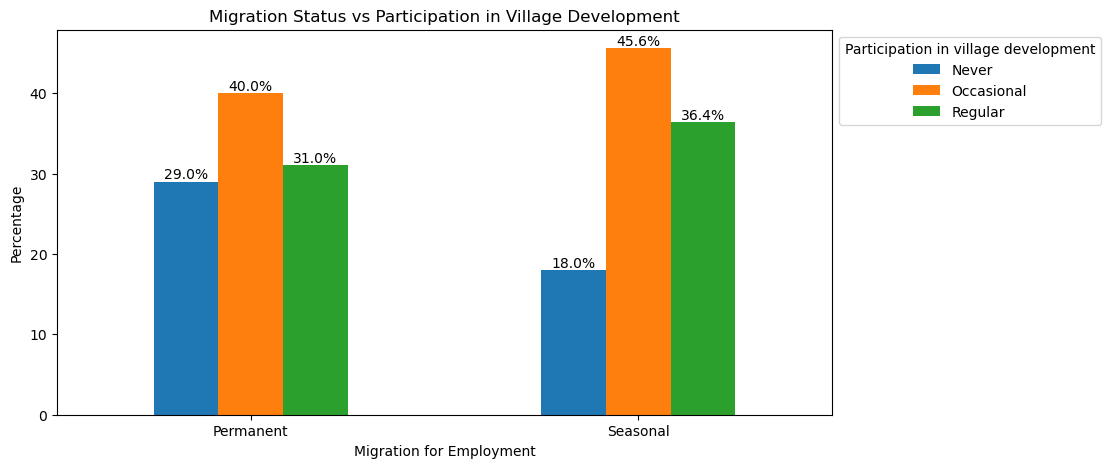

In [178]:
bars = migration_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Migration Status vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Migration for Employment")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Social Category vs Participation (Inclusion)

In [179]:
social_participation = round(pd.crosstab(df['Social Category'], df['Participation in village development'], normalize='index') * 100, 2)
social_participation

Participation in village development,Never,Occasional,Regular
Social Category,,,
General,26.09,44.93,28.99
OBC,28.00,38.67,33.33
Scheduled Caste,32.06,43.06,24.88
Scheduled Tribe,15.38,76.92,7.69


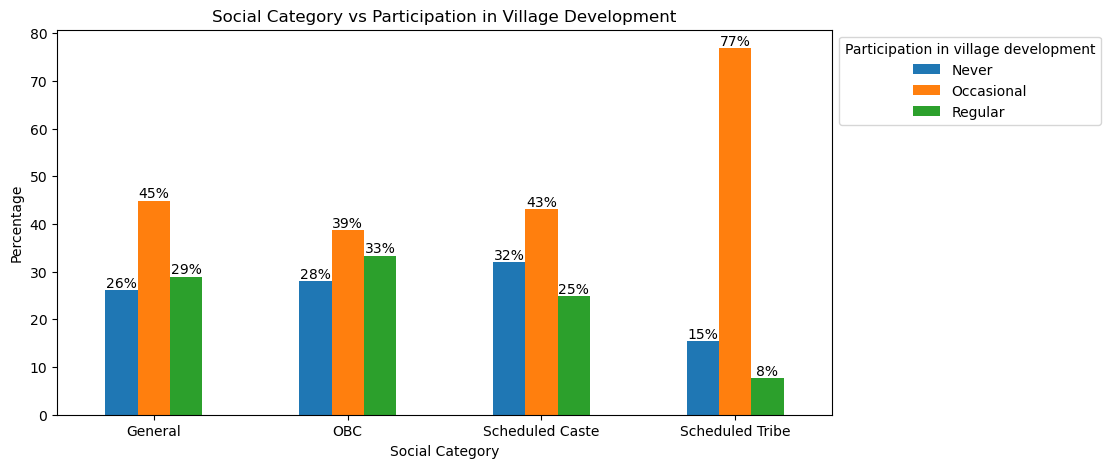

In [180]:
bars = social_participation.plot(kind='bar', figsize=(10,5))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}%',
             ha='center',
             va='bottom')
plt.title("Social Category vs Participation in Village Development")
plt.ylabel("Percentage")
plt.xlabel("Social Category")
plt.legend(title="Participation in village development", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Skill-Demand Mismatch for Livelihoods

# 1. Skill Demand vs Current Occupation (Gap Analysis)

In [181]:
skill_occupation = pd.crosstab(df['Main Occupation'], df['Skills required'])
skill_occupation

Skills required,Agriculture,"Agriculture, Computer","Agriculture, Computer, Driving","Agriculture, Computer, Electrical","Agriculture, Computer, Electrical, Driving","Agriculture, Driving","Agriculture, Electrical","Agriculture, Electrical, Driving","Agriculture, Tailoring","Agriculture, Tailoring, Computer",...,Electrical,"Electrical, Driving",Tailoring,"Tailoring, Computer","Tailoring, Computer, Driving","Tailoring, Computer, Electrical","Tailoring, Computer, Electrical, Driving","Tailoring, Driving","Tailoring, Electrical","Tailoring, Electrical, Driving"
Main Occupation,,,,,,,,,,,,,,,,,,,,,
Agriculture,166,10,3,5,0,9,3,2,14,6,...,3,2,15,6,0,8,2,2,1,0
"Agriculture, Business",6,2,1,0,2,1,0,3,3,1,...,0,0,1,0,0,0,0,0,0,0
"Agriculture, Labour",4,0,0,1,1,2,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
"Agriculture, Labour, Business",0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Agriculture, Labour, Service",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Agriculture, Service",4,0,0,0,0,0,1,2,3,1,...,0,0,3,0,0,0,1,0,0,0
"Agriculture, Service, Business",1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Business,13,3,1,1,0,0,1,2,2,1,...,4,1,5,5,1,1,0,1,0,0
Labour,70,0,0,0,0,2,0,0,8,2,...,5,1,35,4,0,3,4,2,0,0


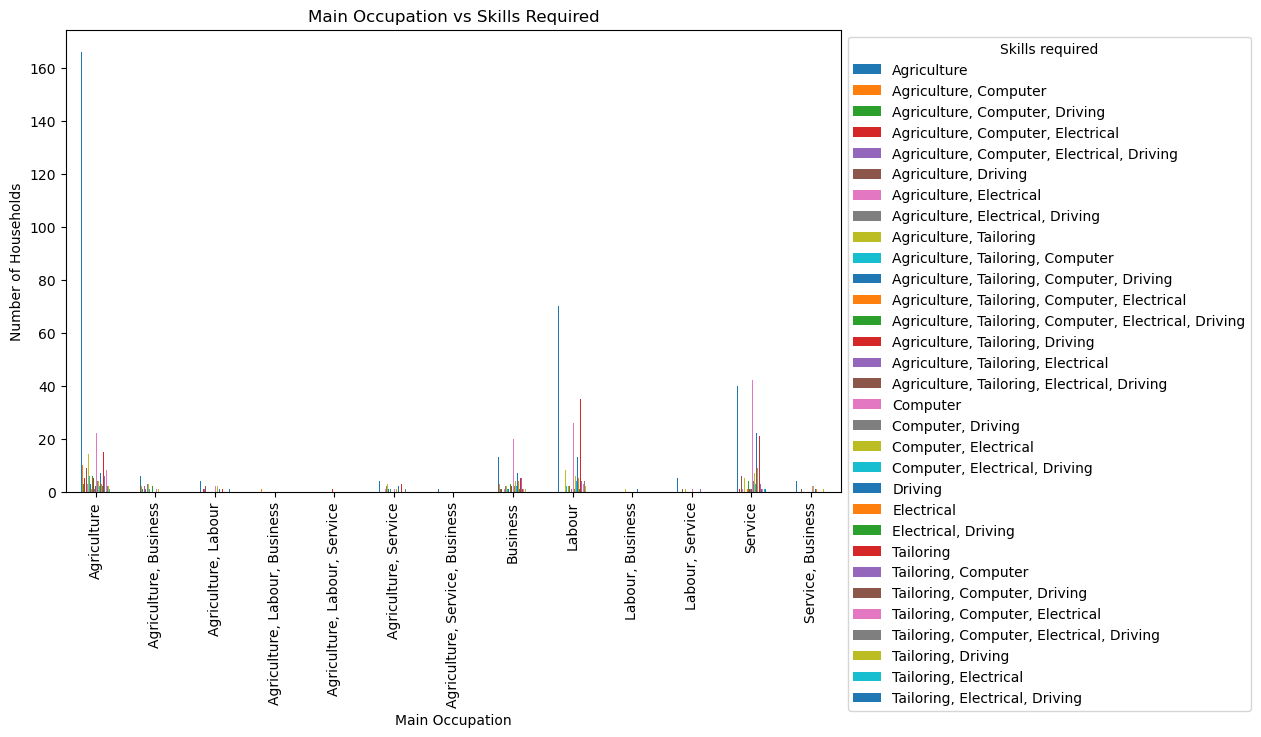

In [182]:
skill_occupation.plot(kind='bar', figsize=(10,6))
plt.title("Main Occupation vs Skills Required")
plt.ylabel("Number of Households")
plt.xlabel("Main Occupation")
plt.legend(title="Skills required", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=90)
plt.show()

# 2. Skill Training vs Household Income (Future Readiness)

In [183]:
skill_income = round(pd.crosstab(df['Skill-trained member in household'], df['Approx. Annual Household Income'], normalize='index') * 100, 2)
skill_income

Approx. Annual Household Income,<1 lakh,1-3 lakh,3-5 lakh,>5 lakh
Skill-trained member in household,,,,
No,38.49,32.18,21.14,8.20
Yes,30.11,35.13,20.45,14.31


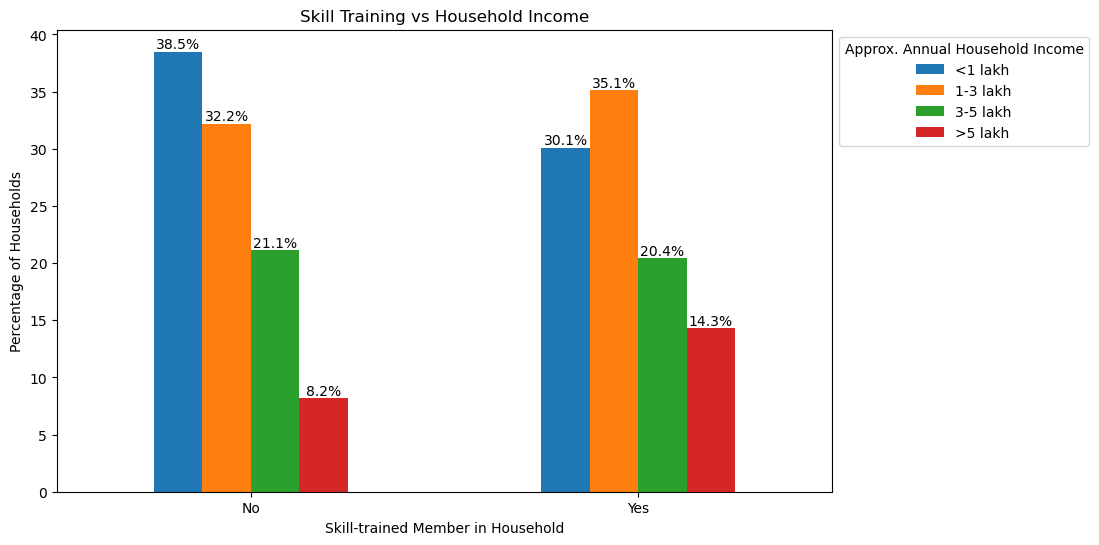

In [184]:
bars = skill_income.plot(kind='bar', figsize=(10,6))
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}%',
             ha='center',
             va='bottom')
plt.title("Skill Training vs Household Income")
plt.ylabel("Percentage of Households")
plt.xlabel("Skill-trained Member in Household")
plt.legend(title="Approx. Annual Household Income", bbox_to_anchor=(1,1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 3. Skills Required Distribution

In [185]:
skills_demand = df['Skills required'].value_counts()
skills_demand

Skills required
Agriculture                                              313
Computer                                                 117
Tailoring                                                 81
Driving                                                   54
Agriculture, Tailoring                                    37
Computer, Electrical                                      27
Electrical                                                22
Agriculture, Driving                                      22
Tailoring, Computer                                       19
Agriculture, Tailoring, Computer, Electrical, Driving     18
Agriculture, Computer                                     18
Tailoring, Computer, Electrical                           13
Computer, Electrical, Driving                             11
Agriculture, Tailoring, Computer                          11
Computer, Driving                                         11
Agriculture, Tailoring, Driving                           10
Agricult

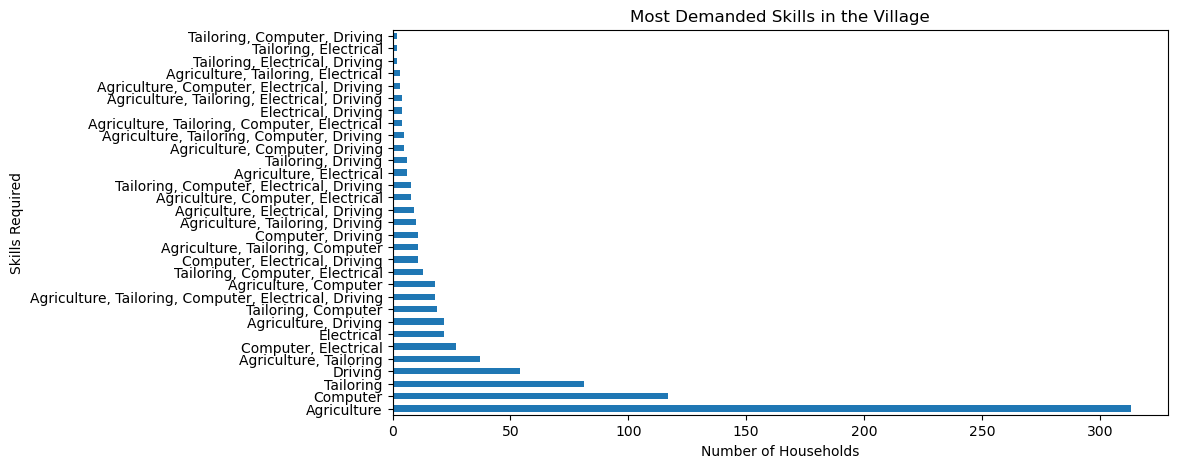

In [186]:
skills_demand.plot(kind='barh', figsize=(10,5))
plt.title("Most Demanded Skills in the Village")
plt.xlabel("Number of Households")
plt.ylabel("Skills Required")
plt.show()